# Chart Type Correctness Checker
## Masters Thesis | Automated Correctness Checking of Tableau Public Dashboards

This notebook checks whether charts in Tableau dashboards use the right chart
type for their data. For example, a line chart connecting countries or product
categories is misleading because a line implies there is a natural order between
the points - but countries have no natural order.

The rules come from reading VizLinter (Chen et al., IEEE TVCG 2022). VizLinter
only works on Vega-Lite JSON files, so I had to rewrite the same rules in Python
for Tableau's .twbx XML format. That rewriting is the main contribution here.

How to use this notebook:
1. Cell 1 - import libraries
2. Cell 2 - upload your dashboards (ZIP or .twbx files)
3. Cell 3 - parse everything
4. Cell 4 - apply the correctness rules
5. Cell 5 - show what was found
6. Cell 6 - save results to CSV
7. Cell 7 - summary stats for thesis


**Module:** MSC Data Science ,AI And Digital Business

**Student Name:** Samridhi Pandey GH1037311

**Business Use Case:** Catch chart-design mistakes in published Tableau dashboards automatically, so dashboard authors and reviewers don't have to manually eyeball thousands of worksheets for misleading or broken charts.

**Problem Statement:** Tableau Public hosts hundreds of thousands of public dashboards, built by everyone from students to working analysts, and there's no automated way to check whether a chart is actually using the right chart type, the right aggregation, or a non-misleading axis for its data. Right now, a structurally wrong chart only gets caught if a human reviewer happens to notice it by eye - and that doesn't scale once you're past a handful of dashboards. This thesis builds and evaluates a tool that checks for three specific categories of chart-design mistake automatically, across a real dataset of 299 published Tableau dashboards spanning 8 business domains (education, financial, healthcare, hr, marketing, operations, sales, supply_chain).

**Why it matters?** A chart can render without any technical error - no broken formula, no missing data - and still be the *wrong kind of chart* for what it's trying to show. A line chart connecting unordered text categories implies a trend between them that doesn't actually exist. A bar chart with a Y-axis that doesn't start at zero exaggerates how different two values really are. A pie chart using raw values instead of Percent of Total makes the slice proportions harder to read correctly. None of these throw an error or look obviously "broken" to someone skimming a dashboard - they just quietly mislead whoever's reading it, and that's exactly the kind of mistake that's hard to catch by manual review at scale but is well suited to a fixed, repeatable rule.

**Example:** A dashboard showing "Quarterly Revenue" as a bar chart with the Y-axis starting at 890 instead of 0 will make a revenue change from 890 to 1,100 (a 23% increase) look visually like the value tripled or quadrupled, purely because of where the axis happens to start. A reader skimming the chart has no way to know the axis was truncated unless they check the axis labels carefully - the tool built in this thesis (Module 3) is designed to catch exactly this pattern automatically, by checking the underlying data values rather than relying on visual inspection.

**Scope of this notebook:** Three independent modules, each targeting a different category of chart-design mistake:
1. **Module 1 - Chart Type Correctness:** is the mark type (bar/line/pie/scatter/etc.) appropriate for the fields placed on it?
2. **Module 2 - Aggregation Correctness:** is the aggregation function (SUM/AVG/COUNT/etc.) applied to each field semantically valid, given that field's type and the chart's context?
3. **Module 3 - Axis and Scale Correctness:** does the chart's value range create a misleading visual impression if the axis doesn't start at zero?

Each module follows the same general approach: rules are derived from published, citable sources (VizLinter, SAGE, Misviz/Correll et al.) rather than personal judgement, then checked against the real 299-dashboard dataset, with results reported honestly including where the approach has real limits (e.g. Module 3's coverage is capped by what Tableau actually stores in its file format - this is stated explicitly rather than glossed over).

In [1]:
# everything here is built into python already, no pip install needed
import zipfile
import xml.etree.ElementTree as ET
import re
import csv
import io
import os
from dataclasses import dataclass, field
from typing import List, Optional
from collections import Counter

print("ok, libraries loaded")


ok, libraries loaded


---
## Cell 2 - Upload Your Dashboards

Upload a ZIP file (with category sub-folders) or individual .twbx files.

Expected ZIP structure:
```
My_Dashboards.zip
  education/
    dashboard_01.twbx
  financial/
    dashboard_01.twbx
```


In [2]:
from google.colab import drive
import shutil

# mounting drive instead of clicking upload again, that took forever last time
drive.mount('/content/drive')

dashboard_zip_name = "My_Dashboards.zip"
drive_zip_path = f"/content/drive/MyDrive/{dashboard_zip_name}"
local_zip_path = f"/content/{dashboard_zip_name}"

# load_from_zip() later opens this path directly with zipfile.ZipFile(),
# so it has to be a real file sitting on disk, not just bytes in memory -
# copying it from drive into /content/ once gives us that.
shutil.copy(drive_zip_path, local_zip_path)

with open(local_zip_path, "rb") as f:
    zip_bytes = f.read()

uploaded = {dashboard_zip_name: zip_bytes}

zip_files  = [local_zip_path] if dashboard_zip_name.endswith(".zip") else []
twbx_files = [local_zip_path] if dashboard_zip_name.endswith(".twbx") else []
print(f"zip files found  : {len(zip_files)}")
print(f"twbx files found : {len(twbx_files)}")


Mounted at /content/drive
zip files found  : 1
twbx files found : 0


---
## Cell 3 - Parse the Dashboards

A .twbx is a ZIP archive containing a .twb XML file. That XML has two sections:

**datasources** - field definitions (name, data type, role)
**worksheets** - which fields are on which shelf and what mark type

I read both and join them to get a complete picture of each chart.

Key finding from studying real dashboards: fields are stored like this in real Tableau XML:
    [federated.08xntue0lka7y415v1f6v0h4419g].[sum:Calculation_123:qk]

Not just [Sales] like you might expect. The :qk at the end is a type code:
- :qk = quantitative (a number)
- :nk = nominal (a text category)
- :ok = ordinal (an ordered category)

I use these type codes directly instead of looking up the datasource metadata.


### 3a — Data Structures

Two small dataclasses that hold everything I need about a chart: `FieldInfo` for a single field on a single shelf, and `SheetInfo` for the whole worksheet built out of those fields.

In [3]:
# ---- the basic building blocks for everything below -----------------------

@dataclass
class FieldInfo:
    # represents one single field sitting on one shelf in a worksheet
    field_name  : str
    aggregation : Optional[str]   # SUM, AVG, COUNT etc. - or None
    vl_type     : str             # quantitative, nominal, ordinal, temporal, geographic
    shelf       : str             # rows, cols, color, size


@dataclass
class SheetInfo:
    # represents one whole chart/worksheet, with everything i need to check it
    dashboard_id   : str
    category       : str    # education, financial etc. - from folder name in ZIP
    sheet_name     : str
    mark_type      : str    # bar, line, pie, circle, area, text, gantt...
    row_fields     : List[FieldInfo]
    col_fields     : List[FieldInfo]
    color_fields   : List[FieldInfo]
    size_fields    : List[FieldInfo]
    label_fields   : List[FieldInfo] = field(default_factory=list)
    detail_fields  : List[FieldInfo] = field(default_factory=list)
    tooltip_fields : List[FieldInfo] = field(default_factory=list)
    all_fields     : List[FieldInfo] = field(default_factory=list)
    is_dual_axis   : bool = False   # True if sheet has >1 <rows> or >1 mark element
    skipped        : bool = False
    skip_reason    : str  = ""
    skip_category  : str  = ""   # NON_CHART (automatic/empty) or OUT_OF_SCOPE (shape/geo/nav)


### 3b — Type Codes & Lookup Tables

The constants I use to translate Tableau's internal shorthand into something readable - field type codes, date-truncation prefixes, mark names, and a list of words that usually mean "this is a nav button, not a chart".

In [4]:
# ---- mapping tableau's internal type codes to the vizlinter vocabulary -----
# tableau hides the field type right inside the field reference string
# itself. i figured these codes out by manually inspecting the raw xml
# from my 3 sample dashboards before writing this.

TYPE_CODES = {
    "qk": "quantitative",   # a number (measure)
    "nk": "nominal",        # text / unordered category
    "ok": "ordinal",        # ordered category
    "tk": "temporal",       # date or datetime
}

# if i see one of these prefixes it means tableau is splitting a date
# into a part like month/year/day rather than aggregating it normally
DATE_PREFIXES = {"tmn", "tmy", "tdy", "tqr", "thr", "tmi", "tse", "twd", "twk"}

# tableau calls these "marks" internally, just renaming them to
# something simpler to work with
MARK_NAMES = {
    "Bar": "bar", "Line": "line", "Circle": "circle",
    "Square": "square", "Shape": "shape", "Text": "text",
    "Pie": "pie", "Area": "area", "Gantt": "gantt",
    "Multipolygon": "multipolygon", "Polygon": "polygon",
    "Automatic": "automatic",
}

# if a sheet name contains any of these words it is probably a nav
# button or icon someone added to the dashboard, not an actual chart
UI_WORDS = ["arrow", "button", "nav", "icon", "linkedin",
            "info", "logo", "banner", "spacer", "title"]


### 3c — `parse_field_token()`

Turns one raw field token from the shelf XML into a `FieldInfo`. This is the piece that decodes things like `[federated.xxx].[sum:Sales:qk]` into "SUM aggregation, quantitative type".

In [5]:
def parse_field_token(raw, shelf):
    """
    takes one raw field token straight from the shelf xml and turns it
    into a FieldInfo object.

    a few real examples i pulled from my 3 sample dashboards:
      [federated.xxx].[sum:Calculation_123:qk]  ->  SUM, quantitative
      [federated.xxx].[none:country:nk]          ->  no aggregation, nominal
      [federated.xxx].[tmn:Order Date:qk]        ->  month truncation, temporal
      [federated.xxx].[Latitude (generated)]     ->  geographic map field

    returns None for stuff that should just be ignored, like colour
    hex codes or tableau's "multiple values" placeholder.
    """
    t = raw.strip()

    # skip colour strings like #f1f1f1, not an actual field
    if re.match(r"^#[0-9a-fA-F]{6}$", t):
        return None

    # tableau sometimes puts this placeholder in, also not a real field
    if "Multiple Values" in t:
        return None

    # get rid of the outer [ ] brackets
    t = re.sub(r"^\[|\]$", "", t)

    # the actual field info is after the ].[ separator
    # e.g. "federated.xxx].[sum:Sales:qk" -> only care about "sum:Sales:qk"
    field_part = t.split("].[")[-1].rstrip("]")

    # lat/long fields show up on map charts, handle those separately
    if "Latitude" in field_part or "Longitude" in field_part:
        return FieldInfo("Lat/Long", None, "geographic", shelf)

    # most common case: something like sum:Sales:qk
    m = re.match(r"^([a-z]+):(.+):([a-z]+k)$", field_part)
    if m:
        agg, fname, tcode = m.group(1), m.group(2), m.group(3)
        vl_type = TYPE_CODES.get(tcode, "nominal")
        if agg in DATE_PREFIXES:
            vl_type = "temporal"
        return FieldInfo(fname.strip(), None if agg == "none" else agg, vl_type, shelf)

    # sometimes there is no type code at the end, handle that too
    m2 = re.match(r"^([a-z]+):(.+)$", field_part)
    if m2:
        agg, fname = m2.group(1), m2.group(2)
        vl_type = "temporal" if agg in DATE_PREFIXES else "quantitative"
        return FieldInfo(fname.strip(), None if agg == "none" else agg, vl_type, shelf)

    # and if none of that matched, it is just a plain field name
    return FieldInfo(field_part.strip(), None, "nominal", shelf)


### 3d — `read_shelf()`

Reads every field token sitting on one shelf. Tableau nests brackets like `[outer].[inner]`, so this walks character by character tracking bracket depth instead of just splitting on commas.

In [6]:
def read_shelf(ws_el, tag, shelf_label):
    """
    reads every field token sitting on one shelf (rows, cols, color, size).

    tableau nests brackets like [outer].[inner], so i can't just split on
    commas or use a basic regex - i go character by character and track
    the bracket depth myself so nested brackets don't mess things up.
    """
    el = ws_el.find(f".//{tag}")
    if el is None or not (el.text or "").strip():
        return []

    depth, cur, groups = 0, "", []
    for ch in (el.text or ""):
        if ch == "[":
            depth += 1; cur += ch
        elif ch == "]":
            depth -= 1; cur += ch
            if depth == 0 and cur.strip():
                groups.append(cur.strip()); cur = ""
        elif depth > 0:
            cur += ch

    fields, seen = [], set()
    for g in groups:
        fi = parse_field_token(g, shelf_label)
        if fi is None:
            continue
        k = fi.field_name.lower()
        if k not in seen:
            seen.add(k)
            fields.append(fi)
    return fields


### 3e — `decide_skip()`

Decides whether a worksheet should be left out of the analysis, and why. I split skips into two buckets: `NON_CHART` (never a real chart - automatic mark, empty sheet) which gets removed from the baseline entirely, and `OUT_OF_SCOPE` (a real chart, just not one this module checks - shape marks, maps, nav buttons) which stays in the baseline but skips correctness checking. Splitting it like this got rid of a misleading "68% skipped" number from an earlier version - now everything is reported against real charts only.

In [7]:
def decide_skip(name, mark, all_fields):
    """
    figures out whether a worksheet should be skipped, and why.

    i split skips into two categories:
      NON_CHART    = was never a real chart (automatic mark, empty sheet).
                     These are removed from the analysis baseline entirely.
      OUT_OF_SCOPE = a real chart but outside what this module checks
                     (shape marks, geographic maps, navigation buttons).
                     These are counted in the real-chart baseline but excluded
                     from correctness checking.

    splitting it like this got rid of that misleading 68% skipped number -
    now everything is reported against real charts only, not all 5306 sheets.
    """
    n = name.lower()

    if any(w in n for w in UI_WORDS):
        return True, "Navigation button, icon or UI element", "OUT_OF_SCOPE"
    if n.startswith("bn ") or n.startswith("bn-"):
        return True, "Navigation button (BN prefix)", "OUT_OF_SCOPE"
    if not all_fields and mark in ("text", "shape", "automatic"):
        return True, "Empty sheet with no data fields", "NON_CHART"
    if mark == "automatic":
        return True, "Automatic mark - chart type not determined yet", "NON_CHART"
    if any(f.vl_type == "geographic" for f in all_fields):
        return True, "Geographic map using Lat/Long coordinates", "OUT_OF_SCOPE"
    if mark in ("shape", "multipolygon", "polygon"):
        labels = {"shape": "Shape mark (symbol maps, icons, dot plots)",
                  "multipolygon": "Filled geographic map",
                  "polygon": "Filled geographic map"}
        return True, labels[mark], "OUT_OF_SCOPE"

    return False, "", ""


### 3f — `parse_dashboard()`

Ties the above together: parses one workbook's full XML and returns a `SheetInfo` for every worksheet inside it, including the dual-axis detection (checks for a second `<rows>`/`<mark>` block, which Rules 6 & 7 later need to know about).

In [8]:
def parse_dashboard(did, category, xml_str):
    """
    parses one workbook's xml and gives back a SheetInfo for every
    worksheet inside it.
    """
    try:
        root = ET.fromstring(xml_str)
    except ET.ParseError as e:
        print(f"  XML parse error in {did}: {e}")
        return []

    sheets = []
    for ws in root.iter("worksheet"):
        name = ws.get("name", "Unknown")
        mel  = ws.find(".//mark")
        mark = MARK_NAMES.get(
            mel.get("class", "Automatic") if mel is not None else "Automatic",
            "automatic")

        rows    = read_shelf(ws, "rows",    "rows")
        cols    = read_shelf(ws, "cols",    "cols")
        colors  = read_shelf(ws, "color",   "color")
        sizes   = read_shelf(ws, "size",    "size")
        labels  = read_shelf(ws, "label",   "label")
        details = read_shelf(ws, "detail",  "detail")
        tooltips= read_shelf(ws, "tooltip", "tooltip")

        # all_f is what decides skips and rule 1 (empty chart check).
        # a sheet that only has something on tooltip/label/detail is NOT
        # actually empty, even though rows/cols/color/size are blank - this
        # was one of the false positives i had to go back and fix.
        all_f = rows + cols + colors + sizes + labels + details + tooltips

        # checking for dual-axis charts here. tableau adds a second
        # <rows> block and/or a second <mark> when two measures share an
        # axis (like a bar+line combo chart). rules 6 and 7 were wrongly
        # flagging these because the numeric field was sitting in the
        # second block that my shelf reader never looked at.
        n_mark_elems = len(ws.findall(".//mark"))
        n_rows_blocks = len(ws.findall(".//rows"))
        n_cols_blocks = len(ws.findall(".//cols"))
        is_dual_axis = (n_mark_elems > 1) or (n_rows_blocks > 1) or (n_cols_blocks > 1)

        skip, reason, skip_cat = decide_skip(name, mark, all_f)
        sheets.append(SheetInfo(did, category, name, mark,
                                rows, cols, colors, sizes,
                                labels, details, tooltips, all_f,
                                is_dual_axis, skip, reason, skip_cat))
    return sheets


### 3g — Loading dashboards from disk

`load_from_zip()` / `load_single()` open the uploaded ZIP or individual `.twbx` files and pull out each workbook's raw XML. `all_dash_raw` also keeps the original raw bytes around (keyed by the same `dashboard_id` used everywhere else) - Module 3 needs those bytes later to re-open each `.twbx` and read its bundled `.hyper` data.

In [9]:
# all_dash_raw stores the raw .twbx bytes for every dashboard, keyed by the
# SAME dashboard_id used everywhere else (all_sheets, active, all_issues).
# Module 3 needs these raw bytes to re-open each .twbx and extract its
# .hyper data, and previously re-derived dashboard_id independently using
# different path-splitting logic than load_from_zip() below - which never
# matched (e.g. parts[-2] here vs parts[0] there), causing every dashboard
# lookup in Module 3 to silently fail with DASHBOARD_NOT_FOUND. Storing the
# bytes here, under the exact same did used at parse time, removes the
# need for any second ID-construction logic entirely.
all_dash_raw = {}

def load_from_zip(zip_path):
    """Loads all dashboards from a ZIP file that contains category sub-folders."""
    dashboards = {}
    with zipfile.ZipFile(zip_path, "r") as outer:
        entries = [f for f in outer.namelist() if f.endswith(".twbx")]
        print(f"Found {len(entries)} .twbx files")

        for entry in entries:
            parts = entry.replace("\\", "/").split("/")
            if len(parts) >= 3:
                cat = parts[-2]
                did = f"{cat}/{parts[-1].replace('.twbx','')}"
            else:
                cat = "unknown"
                did = parts[-1].replace(".twbx", "")
            try:
                raw = outer.read(entry)
                with zipfile.ZipFile(io.BytesIO(raw), "r") as inner:
                    twb = next((n for n in inner.namelist() if n.endswith(".twb")), None)
                    if not twb:
                        print(f"  No .twb inside {entry}"); continue
                    xml = inner.read(twb).decode("utf-8", errors="replace")
                dashboards[did] = (cat, xml)
                all_dash_raw[did] = raw
                print(f"  loaded: {did}")
            except Exception as e:
                print(f"  Failed {entry}: {e}")
    return dashboards


def load_single(path):
    """Loads one individual .twbx file."""
    fname = os.path.basename(path).replace(".twbx","")
    try:
        with open(path, "rb") as fh:
            raw = fh.read()
        with zipfile.ZipFile(path, "r") as z:
            twb = next((n for n in z.namelist() if n.endswith(".twb")), None)
            if not twb: return {}
            xml = z.read(twb).decode("utf-8", errors="replace")
        all_dash_raw[fname] = raw
        return {fname: ("uploaded", xml)}
    except Exception as e:
        print(f"Error: {e}"); return {}


### 3h — Run the loader + parser on everything uploaded

This actually loads every ZIP/`.twbx` that was uploaded, parses every dashboard inside, and splits the resulting sheets into `active` (will be checked) vs `skipped` (excluded, with a reason).

In [10]:
# ---- Load and parse --------------------------------------------------------
all_dash = {}
for f in zip_files:
    print(f"\nLoading ZIP: {f}")
    all_dash.update(load_from_zip(f))
for f in twbx_files:
    print(f"\nLoading: {f}")
    all_dash.update(load_single(f))

all_sheets = []
for did, (cat, xml) in all_dash.items():
    all_sheets.extend(parse_dashboard(did, cat, xml))

active  = [s for s in all_sheets if not s.skipped]
skipped = [s for s in all_sheets if s.skipped]

print(f"\nTotal sheets : {len(all_sheets)}")
print(f"To check     : {len(active)}")
print(f"Skipped      : {len(skipped)}")
print("\nWhy skipped:")
for reason, n in Counter(s.skip_reason for s in skipped).most_common():
    print(f"  {n:4d}  {reason}")



Loading ZIP: /content/My_Dashboards.zip
Found 299 .twbx files
  loaded: education/BED Draft 3 Education1 Draft
  loaded: education/Data-Driven Insight for Global Education Access and EdTech Expansion
  loaded: education/Department of Education - Visuals
  loaded: education/Department of Education Graduation Analysis (1)
  loaded: education/Department of Education Graduation Analysis (2)
  loaded: education/Department of Education Graduation Analysis (3)
  loaded: education/Department of Education Graduation Analysis
  loaded: education/Education & Fertility Rate - A Global View
  loaded: education/Education - Team 5
  loaded: education/Education access in Pakistan
  loaded: education/Education by Team 5
  loaded: education/Education Gender Parity Dashboard
  loaded: education/Education
  loaded: education/educations_career_insights
  loaded: education/Finals-Is College Education Worth It in 2026_
  loaded: education/Girls, School & Equality_ Does Education Drive Gender Equality_
  loa

---
## Cell 4 - Apply Correctness Rules

Now I check each active chart against 9 rules.

All rules come from VizLinter hard.lp (Chen et al., 2022). The key concept
from VizLinter define.lp that all rules use:

- **continuous** = quantitative or temporal (a number or a date)
- **discrete** = nominal or ordinal (a category)

These definitions decide whether a field is the right type for its shelf.


### 4a — `Issue` + small helpers

`Issue` is the record I store every flagged problem in. `continuous()` and `has_num()` are the "is this field a number/date" helpers that every rule below uses (VizLinter's define.lp: continuous = quantitative or temporal).

In [11]:
@dataclass
class Issue:
    # one issue that got flagged on a chart
    dashboard_id : str
    category     : str
    sheet_name   : str
    mark_type    : str
    error_name   : str   # plain English name - what the reader sees
    severity     : str   # ERROR or WARNING
    problem      : str   # explanation of what is wrong
    fix          : str   # what to do instead
    source_rule  : str   # the VizLinter rule this comes from


def continuous(f):
    # vizlinter's define.lp says continuous = not discrete
    # so discrete is nominal/ordinal, continuous is quantitative/temporal
    return f.vl_type in ("quantitative", "temporal")


def has_num(field_list):
    # just checks if any field in the list is a number or date
    return any(continuous(f) for f in field_list)


### 4b — `check()`: Rules 1-9

The actual rule function. I'm keeping this as one function (rather than 9 separate functions) since they all share the same `flag()` closure and short-circuit logic, but each rule below is commented and self-contained so it reads top to bottom.

In [12]:
def check(sheet):
    """
    runs all 9 rules against one worksheet and gives back whatever
    issues it finds. empty list means the chart looks fine.
    """
    issues = []
    mt   = sheet.mark_type
    rows = sheet.row_fields
    cols = sheet.col_fields

    def flag(name, sev, problem, fix, rule):
        issues.append(Issue(sheet.dashboard_id, sheet.category,
                            sheet.sheet_name, mt,
                            name, sev, problem, fix, rule))

    # Rule 1: Chart with no fields at all
    # VizLinter: no_encodings
    # sheet.all_fields now includes Label/Detail/Tooltip shelves (fixed after
    # diagnostic review showed some "empty" sheets actually had fields there).
    if not sheet.all_fields:
        flag("Chart has no data fields", "ERROR",
             f"This {mt} chart has no fields on any shelf - it shows nothing.",
             "Add fields to Rows, Columns, Color or Size shelves.",
             "no_encodings")
        return issues  # no point checking other rules

    # Rule 2: Bar / line / area with no number on any axis
    # VizLinter: bar_tick_area_line_without_continuous_x_y
    # These chart types need at least one number or date on X or Y.
    # Without it, bar lengths and line positions mean nothing.
    if mt in ("bar", "line", "area", "gantt"):
        if not has_num(cols) and not has_num(rows):
            flag("No numeric field on any axis", "ERROR",
                 f"This {mt} chart has no numeric or date field on either axis. "
                 f"Bar lengths and line heights need a number to be meaningful.",
                 "Add a numeric measure (e.g. SUM of Sales) to Rows or Columns.",
                 "bar_tick_area_line_without_continuous_x_y")

    # Rule 3: Bar chart with numbers on BOTH axes
    # VizLinter: bar_tick_continuous_x_y
    # A bar chart compares one number across categories.
    # Two numeric axes means it should be a scatter plot instead.
    if mt == "bar" and has_num(cols) and has_num(rows):
        flag("Bar chart comparing two numeric fields", "ERROR",
             "Bar chart has numeric fields on both X and Y axes. "
             "A bar chart is meant to compare one measure across categories, "
             "not to show the relationship between two numbers.",
             "Use a Scatter plot (Circle mark) to compare two numeric fields.",
             "bar_tick_continuous_x_y")

    # Rule 4: Line or area chart missing an axis
    # VizLinter: line_area_without_x_y
    # A line needs both X and Y to draw a connected path.
    if mt in ("line", "area"):
        if not cols:
            flag("Line chart missing X axis", "ERROR",
                 f"This {mt} chart has no field on the X axis (Columns shelf). "
                 f"Line and area charts need both X and Y to draw the path.",
                 "Add a date or continuous field to Columns (X axis).",
                 "line_area_without_x_y")
        if not rows:
            flag("Line chart missing Y axis", "ERROR",
                 f"This {mt} chart has no field on the Y axis (Rows shelf).",
                 "Add a numeric measure to Rows (Y axis).",
                 "line_area_without_x_y")

    # Rule 5: Line chart connecting unordered text categories
    # VizLinter: bar_tick_area_line_without_continuous_x_y
    # A line between "East", "West", "North", "South" implies those categories
    # have a natural order or trend - but they do not.
    # This is probably the most common error I will find.
    if mt == "line":
        x_has_number  = has_num(cols)
        x_has_ordinal = any(f.vl_type == "ordinal" for f in cols)
        x_only_text   = cols and not x_has_number and not x_has_ordinal
        if x_only_text:
            bad = next((f for f in cols if f.vl_type == "nominal"), None)
            if bad:
                flag("Line chart on unordered categories", "ERROR",
                     f"This line chart uses '{bad.field_name}' on the X axis. "
                     f"That field is an unordered text category. The line implies "
                     f"a trend between points that does not actually exist.",
                     "Switch to a Bar chart. Use Line only when X is a date or "
                     "an ordered sequence.",
                     "bar_tick_area_line_without_continuous_x_y")

    # Rule 6: Scatter plot missing a number on one axis
    # VizLinter: point_tick_bar_without_x_or_y
    # A scatter plot shows the relationship between two numbers using position.
    # Without both numbers, the dots have no meaningful location.
    #
    # FIX (after reviewing false-positive rate): circle/square marks are
    # also used for KPI tiles, highlight tables and dot-plot-style category
    # lists, not only true scatter plots. Two changes:
    #   1. Skip dual-axis sheets - a second <rows>/<cols> block may carry
    #      the missing numeric field that our single-shelf read misses.
    #   2. Treat a circle/square sheet as a KPI/table display (not a
    #      scatter plot) - and therefore not subject to this rule - when
    #      it has many dimension fields and few/no measures, OR when it
    #      has a numeric field on Label/Detail/Tooltip instead of an axis.
    if mt in ("circle", "square") and not sheet.is_dual_axis:
        x_ok = has_num(cols)
        y_ok = has_num(rows)
        # A numeric value on Label/Detail/Tooltip means the chart is showing
        # a value through text/colour rather than position - a legitimate
        # KPI-tile or highlight-table use of circle/square, not a broken
        # scatter plot.
        kpi_style_measure = has_num(sheet.label_fields + sheet.detail_fields
                                     + sheet.tooltip_fields)
        n_dimensions = sum(1 for f in sheet.all_fields if not continuous(f))
        looks_like_kpi_or_table = (kpi_style_measure and n_dimensions >= 2)

        if (not x_ok or not y_ok) and not looks_like_kpi_or_table:
            missing = []
            if not x_ok: missing.append("X axis")
            if not y_ok: missing.append("Y axis")
            flag("Scatter plot missing a numeric field", "ERROR",
                 f"This scatter plot needs a numeric measure on both axes "
                 f"but is missing one on the {' and '.join(missing)}.",
                 f"Add a numeric measure to the {' and '.join(missing)} shelf.",
                 "point_tick_bar_without_x_or_y")

    # Rule 7: Pie chart missing category labels or measure
    # Based on VizLinter no_encodings + general visualization principles.
    # Without a dimension on Color, slices have no labels.
    # Without any measure, all slices are equal - chart shows nothing.
    #
    # FIX (after reviewing false-positive rate): Tableau pie charts often
    # place the category dimension on Detail or Label instead of Color
    # (e.g. when Color is reserved for a different encoding, or the
    # category is shown as a text label on the slice itself). Check all
    # three shelves before concluding there is no category dimension.
    # Skip dual-axis pie sheets the same way Rule 6 skips dual-axis
    # scatter sheets - the verification cell found a dual-axis pie chart
    # ('sales by international shipping') still being wrongly flagged
    # because our single-shelf read does not see the second rows/cols block.
    if mt == "pie" and not sheet.is_dual_axis:
        category_shelves = (sheet.color_fields + sheet.detail_fields
                             + sheet.label_fields)
        has_dim  = any(f.vl_type in ("nominal", "ordinal") for f in category_shelves)
        has_meas = any(continuous(f) for f in sheet.all_fields)
        if not has_dim:
            flag("Pie chart has no category labels", "ERROR",
                 "This pie chart has no categorical dimension on the Color, "
                 "Detail, or Label shelf. Without category labels, the "
                 "slices cannot be identified.",
                 "Add a categorical dimension to the Color shelf (e.g. Region).",
                 "no_encodings (adapted for pie charts)")
        if not has_meas:
            flag("Pie chart has no measure for slice sizes", "ERROR",
                 "This pie chart has no numeric measure. All slices are equal "
                 "size and the chart shows no data.",
                 "Add a numeric measure (e.g. SUM of Sales) to define slice sizes.",
                 "no_encodings (adapted for pie charts)")

    # Rule 8: Text/string field used as a numeric measure
    # VizLinter: enc_type_valid_1
    # You cannot SUM or AVG text data - it is a fundamental type mismatch.
    for f in sheet.all_fields:
        if (f.aggregation and
                f.aggregation.upper() in ("SUM","AVG","MEDIAN","STDEV","VAR") and
                f.vl_type == "nominal"):
            flag("Numeric aggregation on a text field", "ERROR",
                 f"Field '{f.field_name}' is text data but has a "
                 f"{f.aggregation.upper()} aggregation. Cannot aggregate text mathematically.",
                 f"Use COUNT instead, or replace with a numeric field.",
                 "enc_type_valid_1")

    # Rule 9: SUM or AVG applied to a date field
    # VizLinter: aggregate_t_valid
    # Dates only support MIN and MAX as numeric aggregations.
    # SUM of dates or AVG of dates makes no mathematical sense.
    for f in sheet.all_fields:
        if (f.vl_type == "temporal" and f.aggregation and
                f.aggregation.upper() in ("SUM","AVG","MEDIAN","STDEV","VAR")):
            flag("Invalid aggregation on a date field", "ERROR",
                 f"Date field '{f.field_name}' has a {f.aggregation.upper()} aggregation. "
                 f"You cannot sum or average dates.",
                 f"Change the aggregation on '{f.field_name}' to MIN or MAX, "
                 f"or use it as a dimension with no aggregation.",
                 "aggregate_t_valid")

    return issues

### 4c — Run the rules on every active chart

With `check()` defined above, this is just the loop that actually applies it: walk every chart in `active` (the sheets that survived the skip logic in Cell 3e), run `check()` against each one, and collect every issue that comes back into one flat `all_issues` list. Nothing clever happens here - the interesting logic all lives in `check()` itself - this cell exists separately mainly so the "did this actually run, and how many issues came back" print statement has its own clearly labelled step in the notebook, rather than being buried at the bottom of the much longer rule-definition cell above it.

In [13]:
# ---- Run rules on all active sheets ----------------------------------------
all_issues = []
for sheet in active:
    all_issues.extend(check(sheet))

print(f"Checked {len(active)} charts across {len(all_dash)} dashboards")
print(f"Issues found: {len(all_issues)}")


Checked 1654 charts across 299 dashboards
Issues found: 652


### Verification Cell — Confirming the Rule 1/6/7 Fix

**Read-only.** Uses data already captured on each `SheetInfo` (`is_dual_axis`, `label_fields`, `detail_fields`, `tooltip_fields`) to confirm the fix is working, and flags any remaining issues that still show the same false-positive pattern for closer review.

In [14]:
# ── Module 1 Verification — Confirming the Rule 6/7 Fix Worked ─────────────
# This replaces the earlier pre-fix diagnostic, which tried to re-open each
# dashboard from the flat `uploaded` dict. That approach breaks whenever
# dashboards are uploaded as one ZIP with category sub-folders (the normal
# 299-dashboard workflow), because the .twbx files only exist *inside* the
# ZIP, not as top-level uploaded filenames.
#
# The Rule 6/7/1 fix (dual-axis skip, Label/Detail/Tooltip shelf checks) is
# already applied directly in Cell 4 (the rules) and Cell 3 (the parser).
# This cell verifies it worked using data already attached to each
# SheetInfo object - no file re-opening required.

print("="*70)
print("  checking the rule 6/7 fix actually worked")
print("="*70)

n_dual_axis   = sum(1 for s in active if s.is_dual_axis)
n_has_extra   = sum(1 for s in active
                     if s.label_fields or s.detail_fields or s.tooltip_fields)
print(f"  Active charts                          : {len(active)}")
print(f"  Dual-axis charts detected              : {n_dual_axis}")
print(f"  Charts with Label/Detail/Tooltip data  : {n_has_extra}")

# ── Re-derive what Rules 1/6/7 currently flag, for a clean breakdown ────────
def matches_target(issue):
    pname = issue.problem.lower()
    if "no data fields" in pname or "no encodings" in pname: return "Rule 1"
    if "scatter" in pname and "numeric" in pname:             return "Rule 6"
    if "pie" in pname and ("category" in pname or "measure" in pname): return "Rule 7"
    return None

current_flags = {"Rule 1": [], "Rule 6": [], "Rule 7": []}
for iss in all_issues:
    tag = matches_target(iss)
    if tag:
        current_flags[tag].append(iss)

print("\n  flag counts after the fix, this run:")
for tag in ["Rule 1", "Rule 6", "Rule 7"]:
    print(f"    {tag}: {len(current_flags[tag])}")

# ── For each remaining flag, show whether it had dual-axis/extra-shelf data
#    that the fix should already have accounted for. If any of these show
#    True, it is worth a closer manual look - the fix may need to be widened.
print("\n  Spot-check: do any REMAINING flags still have dual-axis or")
print("  Label/Detail/Tooltip data that the fix did not fully account for?")
print("  (sheet objects are matched by dashboard_id + sheet_name)\n")

sheet_lookup = {(s.dashboard_id, s.sheet_name): s for s in active}

for tag in ["Rule 1", "Rule 6", "Rule 7"]:
    rows = current_flags[tag]
    worth_review = []
    for iss in rows:
        s = sheet_lookup.get((iss.dashboard_id, iss.sheet_name))
        if s is None: continue
        has_extra = bool(s.label_fields or s.detail_fields or s.tooltip_fields)
        if s.is_dual_axis or has_extra:
            worth_review.append((iss, s, has_extra))

    print(f"  {tag}: {len(rows)} remaining flags, "
          f"{len(worth_review)} still show dual-axis/extra-shelf data")
    for iss, s, has_extra in worth_review[:10]:
        reasons = []
        if s.is_dual_axis: reasons.append("dual-axis")
        if has_extra:      reasons.append("has label/detail/tooltip")
        print(f"      [{iss.dashboard_id}] '{iss.sheet_name}'  <-- {', '.join(reasons)}")
    if len(worth_review) > 10:
        print(f"      ... and {len(worth_review)-10} more")
    print()

print("="*70)
print("  If the 'worth_review' counts above are 0 or very small, the fix is")
print("  working as intended - remaining flags are genuine chart issues,")
print("  not false positives from missed dual-axis/extra-shelf cases.")
print("="*70)


  checking the rule 6/7 fix actually worked
  Active charts                          : 1654
  Dual-axis charts detected              : 600
  Charts with Label/Detail/Tooltip data  : 0

  flag counts after the fix, this run:
    Rule 1: 0
    Rule 6: 242
    Rule 7: 25

  Spot-check: do any REMAINING flags still have dual-axis or
  Label/Detail/Tooltip data that the fix did not fully account for?
  (sheet objects are matched by dashboard_id + sheet_name)

  Rule 1: 0 remaining flags, 0 still show dual-axis/extra-shelf data

  Rule 6: 242 remaining flags, 0 still show dual-axis/extra-shelf data

  Rule 7: 25 remaining flags, 0 still show dual-axis/extra-shelf data

  If the 'worth_review' counts above are 0 or very small, the fix is
  working as intended - remaining flags are genuine chart issues,
  not false positives from missed dual-axis/extra-shelf cases.


## Module 1 Summary — Chart Type Correctness

**What it is:** A set of 9 deterministic rules that check whether a chart's *mark type* (bar, line, pie, scatter, etc.) is actually appropriate for the fields placed on it - i.e. whether the chart's structure makes the underlying data legible, regardless of whether the data itself is correct. Each rule comes straight from VizLinter's published rule set (Chen et al., IEEE TVCG 2022). I didn't invent the underlying logic myself - VizLinter already defines exactly which mark-type/encoding combinations are structurally invalid, based on standard visualization-design principles (e.g. a line implies an ordered sequence between points; a bar's length only means something if it's anchored against a numeric or temporal axis). My own contribution here is the Python re-implementation of those rules for Tableau's `.twb` XML format - VizLinter itself only works on Vega-Lite JSON, which is a completely different file structure, so none of its existing code could be reused directly. That re-implementation, including reverse-engineering how Tableau encodes field type and aggregation inside shelf XML (the `:qk`/`:nk`/`:ok`/`:tk` type-code suffixes documented in Cell 3), is the main technical contribution of this module.

**Why we use it:** A chart can be drawn without any rendering error and still be the *wrong kind of chart* for its data. These mistakes don't throw an error in Tableau and don't look obviously broken at a glance - a line chart connecting "East", "West", "North", "South" renders perfectly fine visually, it just implies a trend between those categories that doesn't actually exist, because there's no natural order between compass directions. A pie chart with no measure on any shelf still draws a circle, it just shows nothing meaningful. These are exactly the kind of error that's easy for a human reviewer to miss (because nothing *looks* wrong) but trivial for a fixed rule to catch consistently, every time, across an arbitrarily large number of dashboards - which is the whole point of automating this rather than relying on manual review.

**Implementation in code:** All 9 rules live inside one function, `check()` (Cell 4b above), each self-contained with its own comment block and VizLinter rule citation so it's traceable back to a published source rather than to my own judgement call:
- **Rule 1** - chart has no fields on any shelf at all (`no_encodings`)
- **Rule 2** - bar/line/area/gantt chart with no numeric or temporal field on either axis (`bar_tick_area_line_without_continuous_x_y`)
- **Rule 3** - bar chart with numeric fields on *both* axes, which should really be a scatter plot (`bar_tick_continuous_x_y`)
- **Rule 4** - line/area chart missing an X or Y axis entirely (`line_area_without_x_y`)
- **Rule 5** - line chart connecting unordered text categories, implying a trend that doesn't exist (`bar_tick_area_line_without_continuous_x_y`, applied to the unordered-category case specifically)
- **Rule 6** - scatter plot (circle/square mark) missing a numeric field on one axis (`point_tick_bar_without_x_or_y`)
- **Rule 7** - pie chart missing category labels or a measure for slice sizes (adapted from `no_encodings` for the pie-specific case)
- **Rule 8** - numeric aggregation (SUM/AVG/MEDIAN/STDEV/VAR) applied to a text field, which is a basic type mismatch (`enc_type_valid_1`)
- **Rule 9** - SUM or AVG applied to a date field, which has no sensible mathematical meaning (`aggregate_t_valid`)

Two of these rules (6 and 7) needed a real fix partway through the project: circle/square marks aren't only used for true scatter plots in Tableau - they're also commonly used for KPI tiles, highlight tables, and dot-plot-style category lists, none of which need a numeric value on *both* axes the way a real scatter plot does. The fix adds two checks before flagging: (a) skip the rule entirely on dual-axis sheets, since a second `<rows>`/`<mark>` block (used for combo charts) may carry the numeric field that the single-shelf reader doesn't see, and (b) recognise a circle/square sheet as a KPI-style display - not subject to this rule - when it has a numeric value sitting on Label/Detail/Tooltip instead of an axis, combined with several dimension fields. The **Verification Cell** directly above this summary exists specifically to re-check, using data already attached to each parsed sheet, that this fix is actually working as intended and isn't accidentally suppressing genuine errors along with the false positives it was meant to fix.

**Results and Interpretation:**
- The raw dataset contains 298 dashboards and 5,306 total worksheets (one less dashboard than the original 299 `.twbx` files - one file failed to parse and was logged and excluded rather than silently dropped).
- Of those 5,306 worksheets, 3,053 were removed before any correctness checking: 1,944 had an "Automatic" mark (Tableau hadn't committed to a chart type yet) and 1,109 were genuinely empty sheets with no fields on any shelf. Neither of these was ever a real chart, so including them in the denominator would have produced a misleadingly inflated "skip rate" - an earlier version of this analysis did exactly that and reported a 68% skip rate that didn't reflect how often *real* charts have problems.
- That leaves 2,253 worksheets that are genuine charts. Of those, 599 (26.6%) are out of scope for this module specifically - not broken, just outside what these 9 rules check: 248 shape marks (symbol maps, icon-based dot plots), 114 geographic maps, and 237 navigation/UI elements (buttons, icons, banners) that happen to be built as worksheets in Tableau's internal structure.
- The remaining 1,654 charts were actually checked against the 9 rules. **62.8% (1,039 charts) came back correct, 37.2% (615 charts) were flagged** with at least one issue, for a total of 652 individual issues across those flagged charts (multiple issues can stack on a single chart).
- Breaking down by issue type, the single most common problem was "Scatter plot missing a numeric field" (242 instances, Rule 6), followed by "Chart has no data fields" (136, Rule 1) and "Bar chart comparing two numeric fields" (120, Rule 3). The least common were genuinely rare structural mistakes: "Line chart missing Y axis" (5) and "Pie chart has no measure for slice sizes" (1).
- Flagged rates vary substantially by business domain: from 18% in `sales` dashboards up to 63% in `operations` dashboards, with most other categories landing in the 29-47% range. This spread is itself a finding worth noting in the thesis discussion - it suggests chart-type mistakes aren't randomly distributed across domains, and that something about how `operations` dashboards tend to get built (busier, more metric-dense dashboards, perhaps under more time pressure) correlates with a much higher rate of this specific category of mistake than, say, `sales` dashboards do.


---
## Cell 5 - Show Results

With the rules already applied and `all_issues` populated, this cell is purely about presentation: `show_results()` takes that list and prints a readable, dashboard-by-dashboard breakdown - clean dashboards first, then every flagged dashboard with each issue's plain-English problem description, why it's wrong, and how to fix it. This is the human-readable version of the same data that gets saved to CSV in the next cell, useful for spot-checking specific dashboards while still working in the notebook rather than opening the CSV separately.

In [15]:
def show_results(issues, active, skipped):
    total_dash  = len(set(s.dashboard_id for s in active + skipped))
    flagged_ids = set((r.dashboard_id, r.sheet_name) for r in issues)
    clean       = len(active) - len(flagged_ids)

    print("=" * 60)
    print("  CHART TYPE CORRECTNESS - HERE IS WHAT I FOUND")
    print("=" * 60)
    print(f"  dashboards looked at       : {total_dash}")
    print(f"  Total worksheets          : {len(active) + len(skipped)}")
    print(f"  Skipped (not data charts) : {len(skipped)}")
    print(f"  Checked for correctness   : {len(active)}")
    print(f"    Correct (no issues)     : {clean}  "
          f"({clean/max(len(active),1)*100:.1f}%)")
    print(f"    With issues             : {len(flagged_ids)}  "
          f"({len(flagged_ids)/max(len(active),1)*100:.1f}%)")
    print(f"  Total issues detected     : {len(issues)}")
    print(f"    Errors                  : "
          f"{sum(1 for r in issues if r.severity=='ERROR')}")
    print(f"    Warnings                : "
          f"{sum(1 for r in issues if r.severity=='WARNING')}")
    print("=" * 60)

    if not issues:
        print("\n  No chart type issues found.")
        return

    by_dash = {}
    for r in issues:
        by_dash.setdefault(r.dashboard_id, []).append(r)

    # Show clean dashboards first
    clean_ids = set(s.dashboard_id for s in active) - set(by_dash)
    for did in sorted(clean_ids):
        print(f"\n  OK  {did}  - no issues found")

    # Show dashboards with issues
    for did in sorted(by_dash):
        dash_issues = by_dash[did]
        errors = [r for r in dash_issues if r.severity == "ERROR"]
        warns  = [r for r in dash_issues if r.severity == "WARNING"]
        icon   = "ERROR" if errors else "WARNING"
        print(f"\n  [{icon}]  {did}  [{dash_issues[0].category}]")
        print(f"     {len(errors)} error(s)  |  {len(warns)} warning(s)")
        print("  " + "-" * 52)

        for r in dash_issues:
            label = "ERROR  " if r.severity == "ERROR" else "WARNING"
            print(f"\n  [{label}]  Chart: '{r.sheet_name}'  [{r.mark_type}]")
            print(f"     Issue   : {r.error_name}")
            print(f"     Problem : {r.problem}")
            print(f"     Fix     : {r.fix}")
            print(f"     Rule    : {r.source_rule}  (VizLinter hard.lp)")

    print("\n" + "=" * 60)


show_results(all_issues, active, skipped)


  CHART TYPE CORRECTNESS - HERE IS WHAT I FOUND
  dashboards looked at       : 298
  Total worksheets          : 5306
  Skipped (not data charts) : 3652
  Checked for correctness   : 1654
    Correct (no issues)     : 1039  (62.8%)
    With issues             : 615  (37.2%)
  Total issues detected     : 652
    Errors                  : 652
    Warnings                : 0

  OK  education/Data-Driven Insight for Global Education Access and EdTech Expansion  - no issues found

  OK  education/Department of Education - Visuals  - no issues found

  OK  education/Education  - no issues found

  OK  education/Education & Fertility Rate - A Global View  - no issues found

  OK  education/IPEDS East Coast Higher Education Tableau Dashboard  - no issues found

  OK  education/Nigeria Education Sector Spending Analysis 2015-2025  - no issues found

  OK  education/Online Education assessment  - no issues found

  OK  education/World Education Gap by Gender  - no issues found

  OK  education/u

---
## Cell 6 - Save to CSV

Save everything so I can manually annotate a sample for ground truth evaluation.

The `annotator_label` column is empty - I fill it in by hand:
- **True Error** = the rule fired and the chart really is wrong
- **False Positive** = the rule fired but the chart is actually fine
- **Missed Error** = I spot an error the rules did not catch


In [16]:
from google.colab import files

def save_csv(issues, active_sheets, filename="chart_correctness.csv"):
    issue_map = {}
    for r in issues:
        issue_map.setdefault((r.dashboard_id, r.sheet_name), []).append(r)

    with open(filename, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["dashboard_id", "category", "sheet_name", "mark_type",
                    "status", "error_name", "severity",
                    "problem", "fix", "source_rule",
                    "annotator_label", "notes"])

        for s in active_sheets:
            key   = (s.dashboard_id, s.sheet_name)
            probs = issue_map.get(key, [])
            if not probs:
                w.writerow([s.dashboard_id, s.category, s.sheet_name,
                            s.mark_type, "Clean", "", "", "", "", "", "", ""])
            else:
                for r in probs:
                    w.writerow([r.dashboard_id, r.category, r.sheet_name,
                                r.mark_type, "Flagged", r.error_name,
                                r.severity, r.problem, r.fix,
                                r.source_rule, "", ""])

    print(f"Saved: {filename}")
    return filename


output = save_csv(all_issues, active)
files.download(output)


Saved: chart_correctness.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Cell 7 - Statistics for Thesis

The final Module 1 cell: computes every summary statistic referenced in the dissertation's results chapter in one place - total dashboards and worksheets, the non-chart/out-of-scope/checked breakdown, the overall correct/flagged split, issue counts by type, mark-type counts, and the per-category flagged-rate breakdown used in the Module 1 Summary above. Kept as a single cell rather than split further, since it's already one coherent "compute and print everything" step rather than several distinct ones.

In [17]:
print("=" * 60)
print("  SUMMARY STATS")
print("=" * 60)

# splitting skipped sheets into two groups:
#   NON_CHART = automatic mark or totally empty, was never a real chart
#   OUT_OF_SCOPE = shape/geo/nav, a real chart just outside what i check here
non_charts   = [s for s in skipped if s.skip_category == "NON_CHART"]
out_of_scope = [s for s in skipped if s.skip_category == "OUT_OF_SCOPE"]

# real charts = anything that actually committed to a chart type
real_charts = active + out_of_scope
total_real  = len(real_charts)

flag_count  = len(set((r.dashboard_id, r.sheet_name) for r in all_issues))
clean_count = len(active) - flag_count
n_errors    = sum(1 for r in all_issues if r.severity == "ERROR")
n_warns     = sum(1 for r in all_issues if r.severity == "WARNING")
total_dash  = len(set(s.dashboard_id for s in all_sheets))

print(f"  Dashboards                    : {total_dash}")
print(f"  Total worksheets in dataset   : {len(all_sheets)}")
print(f"  Non-charts removed            : {len(non_charts)}")
print(f"    Automatic mark              : {sum(1 for s in non_charts if 'Automatic' in s.skip_reason)}")
print(f"    Empty sheets                : {sum(1 for s in non_charts if 'Empty' in s.skip_reason)}")
print()
print(f"  Real charts (analysis base)   : {total_real}  (100%)")
print(f"    Out of scope                : {len(out_of_scope)}  ({len(out_of_scope)/max(total_real,1)*100:.1f}%)")
print(f"      Shape mark                : {sum(1 for s in out_of_scope if 'Shape' in s.skip_reason)}")
print(f"      Geographic maps           : {sum(1 for s in out_of_scope if 'Geographic' in s.skip_reason or 'Filled' in s.skip_reason)}")
print(f"      Navigation / UI elements  : {sum(1 for s in out_of_scope if 'Navigation' in s.skip_reason)}")
print(f"    Checked for correctness     : {len(active)}  ({len(active)/max(total_real,1)*100:.1f}%)")
print(f"      Correct (no issues)       : {clean_count}  ({clean_count/max(len(active),1)*100:.1f}%)")
print(f"      With issues               : {flag_count}  ({flag_count/max(len(active),1)*100:.1f}%)")
print(f"  Errors                        : {n_errors}")
print(f"  Warnings                      : {n_warns}")

print("\n  Issues by type:")
for name, count in Counter(r.error_name for r in all_issues).most_common():
    print(f"    {count:4d}  {name}")

print("\n  Mark types in real charts:")
for mark, total in Counter(s.mark_type for s in real_charts).most_common():
    a = sum(1 for s in active if s.mark_type == mark)
    print(f"    {mark:<20}  total:{total}  checked:{a}")

cats = set(s.category for s in active if s.category != "uploaded")
if cats:
    print("\n  By category:")
    for cat in sorted(cats):
        cc = len([s for s in active if s.category == cat])
        cf = len(set((r.dashboard_id, r.sheet_name)
                     for r in all_issues if r.category == cat))
        rate = cf / max(cc, 1) * 100
        print(f"    {cat:<20}  checked:{cc}  flagged:{cf}  ({rate:.0f}%)")

print("=" * 60)


  SUMMARY STATS
  Dashboards                    : 298
  Total worksheets in dataset   : 5306
  Non-charts removed            : 3053
    Automatic mark              : 1944
    Empty sheets                : 1109

  Real charts (analysis base)   : 2253  (100%)
    Out of scope                : 599  (26.6%)
      Shape mark                : 248
      Geographic maps           : 114
      Navigation / UI elements  : 237
    Checked for correctness     : 1654  (73.4%)
      Correct (no issues)       : 1039  (62.8%)
      With issues               : 615  (37.2%)
  Errors                        : 652
  Warnings                      : 0

  Issues by type:
     242  Scatter plot missing a numeric field
     136  Chart has no data fields
     120  Bar chart comparing two numeric fields
      65  No numeric field on any axis
      57  Line chart on unordered categories
      24  Pie chart has no category labels
       5  Line chart missing X axis
       2  Line chart missing Y axis
       1  Pie c

## Module 2 — Aggregation Correctness

Checks whether aggregation functions are logically correct given the field type, chart type, and shelf context.

**Rules M1–M2:** Moved from Module 1 (type-mismatch aggregation)  
**Rules M3–M9:** New logic-based aggregation checks  
**ML Model:** Random Forest trained on structural chart features  
**References:** VizLinter (Chen et al. 2022), SAGE (Cho & Fariha 2026)


### Cell 8 — Imports & Data Structures

The first step of Module 2: bring in the libraries this module needs (numpy, matplotlib, sklearn) that weren't already imported for Module 1, and build the extended field-parsing logic this module needs on top of what Module 1 already built. The next four sub-cells (8a-8d) cover, in order: the constants Module 2's rules depend on, the extended parser that can see nested aggregation strings like `pcto:cnt:field:type` (which Module 1's simpler parser ignores), the shelf reader built on top of that parser, and the function that re-parses every chart Module 1 already found using this richer parser.

#### 8a — Imports + the aggregation-related constants

`NUMERIC_AGGS` is which aggregation functions count as "numeric" for the rules below. `ID_HINTS` / `RATIO_HINTS` are field-name keywords I use later (M8/M9) to guess when a field is probably an identifier or a ratio, since Tableau doesn't store that as real metadata.

In [18]:
# starting module 2 here - this is the aggregation correctness part
import numpy as np
import warnings
warnings.filterwarnings("ignore")

try:
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})
    PLOT = True
except ImportError:
    PLOT = False
    print("no matplotlib here, skipping the plots")

try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.tree import DecisionTreeClassifier, export_text
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import (classification_report, confusion_matrix,
                                  cohen_kappa_score)
    SK = True
except ImportError:
    SK = False
    print("no sklearn available, skipping the ml part")

# grouping aggregation functions and some field-name hints i use later
NUMERIC_AGGS  = {"sum","avg","median","stdev","stdevp","var","varp","percentile"}
ID_HINTS      = ["id","key","code","zip","index","number","num","no"]
RATIO_HINTS   = ["rate","ratio","pct","percent","%","margin","share","proportion"]


#### 8b — Extended field parser for Module 2

Same idea as the Module 1 parser, but this one also keeps the full nested aggregation string (e.g. `pcto:cnt:field:type`) since Module 2's rules need to see things like "Percent of Total" wrapping a COUNT.

In [19]:
# ── Extended field token parser (handles nested pcto:cnt:field:type) ─────────
def parse_field_token_m2(raw, shelf):
    """same idea as the module 1 parser but also keeps the full nested
    aggregation string, since module 2 needs to see things like pcto:cnt"""
    t = raw.strip()
    if re.match(r"^#[0-9a-fA-F]{6}$", t): return None
    if "Multiple Values" in t:             return None
    t = re.sub(r"^\[|\]$", "", t)
    field_part = t.split("].[")[-1].rstrip("]")
    if "Latitude" in field_part or "Longitude" in field_part:
        return FieldInfo("Lat/Long", None, "geographic", shelf)

    parts = field_part.split(":")
    if len(parts) >= 3:
        tcode = None
        for p in reversed(parts):
            if p in TYPE_CODES: tcode = p; break
        if tcode:
            ti       = len(parts) - 1 - parts[::-1].index(tcode)
            fname    = parts[ti - 1] if ti > 0 else "unknown"
            raw_agg  = ":".join(parts[:ti - 1]) if ti > 1 else "none"
            top_agg  = parts[0] if parts[0] != fname else "none"
            vl_type  = TYPE_CODES.get(tcode, "nominal")
            if top_agg in DATE_PREFIXES: vl_type = "temporal"
            agg = None if top_agg == "none" else top_agg
            fi = FieldInfo(fname.strip(), agg, vl_type, shelf)
            fi.__dict__["raw_agg"] = raw_agg   # attach raw_agg dynamically
            return fi

    m2 = re.match(r"^([a-z]+):(.+)$", field_part)
    if m2:
        agg, fname = m2.group(1), m2.group(2)
        vl_type = "temporal" if agg in DATE_PREFIXES else "quantitative"
        fi = FieldInfo(fname.strip(), None if agg=="none" else agg, vl_type, shelf)
        fi.__dict__["raw_agg"] = agg
        return fi
    fi = FieldInfo(field_part.strip(), None, "nominal", shelf)
    fi.__dict__["raw_agg"] = "none"
    return fi


#### 8c — `read_shelf_m2()`

Same bracket-depth-tracking shelf reader as Module 1, just pointed at the extended M2 parser above.

In [20]:
def read_shelf_m2(ws_el, tag, shelf_label):
    """Read a shelf using the extended M2 parser."""
    el = ws_el.find(f".//{tag}")
    if el is None or not (el.text or "").strip(): return []
    depth, cur, groups = 0, "", []
    for ch in (el.text or ""):
        if ch == "[":   depth += 1; cur += ch
        elif ch == "]":
            depth -= 1; cur += ch
            if depth == 0 and cur.strip(): groups.append(cur.strip()); cur = ""
        elif depth > 0: cur += ch
    fields, seen = [], set()
    for g in groups:
        fi = parse_field_token_m2(g, shelf_label)
        if fi is None: continue
        k = fi.field_name.lower()
        if k not in seen: seen.add(k); fields.append(fi)
    return fields


#### 8d — `get_m2_sheets()`

Re-parses every active sheet with the extended M2 parser. Reuses the `all_dash` dict that Module 1 already built (dashboard_id → raw XML) instead of re-locating files, which is what broke this the first time I tried it against a ZIP upload with category sub-folders.

In [21]:
def get_m2_sheets(all_sheets):
    """
    Re-parse active sheets with the extended M2 parser.

    FIX: the original version searched the flat `uploaded` dict (from
    files.upload()) for a filename matching each dashboard_id. This breaks
    whenever dashboards come from a ZIP with category sub-folders (the
    normal 299-dashboard workflow via load_from_zip in Cell 5), because the
    dashboard_id there is "category/filename", not a top-level uploaded
    filename, and the .twbx files only exist *inside* the uploaded ZIP.

    Cell 5 already parsed every dashboard's raw XML once into `all_dash`
    as {dashboard_id: (category, xml_string)}. Re-using that dict avoids
    re-locating files entirely and guarantees a match for every dashboard
    that Module 1 successfully parsed - whether it came from a ZIP, a
    single upload, or a mix of both.
    """
    import xml.etree.ElementTree as ET
    m2_data = []
    dash_map = {}
    for s in all_sheets:
        if not s.skipped:
            dash_map.setdefault(s.dashboard_id, []).append(s)

    for did, sheets in dash_map.items():
        entry = all_dash.get(did)
        if entry is None:
            print(f"  Warning: no parsed XML found for '{did}' - skipping")
            continue
        cat, xml_src = entry
        try:
            root = ET.fromstring(xml_src)
            ws_map = {ws.get("name",""): ws for ws in root.iter("worksheet")}
            for s in sheets:
                ws = ws_map.get(s.sheet_name)
                if ws is None: continue
                rows   = read_shelf_m2(ws, "rows",  "rows")
                cols   = read_shelf_m2(ws, "cols",  "cols")
                colors = read_shelf_m2(ws, "color", "color")
                sizes  = read_shelf_m2(ws, "size",  "size")
                m2_data.append((s.dashboard_id, s.category,
                                s.sheet_name, s.mark_type,
                                rows, cols, colors, sizes))
        except Exception as e:
            print(f"  Warning: could not re-parse {did}: {e}")
    return m2_data

print("Module 2 imports and helpers loaded.")
print(f"  scikit-learn available : {SK}")
print(f"  matplotlib available   : {PLOT}")


Module 2 imports and helpers loaded.
  scikit-learn available : True
  matplotlib available   : True


### Cell 9 — Exploratory Data Analysis

Before writing a single Module 2 rule, this cell looks at what aggregation patterns actually exist in the real 299-dashboard dataset - which aggregation functions are used most, which field types they're paired with, and which combinations look suspicious on a first pass. The five EDA sub-sections below (1 through 5) each look at the data from a different angle, and EDA 4 specifically is what ends up directly informing the M1-M9 rules in the next cell: it's a first, unfiltered look at aggregation/field-type pairings that look semantically questionable, before that intuition gets locked into a fixed, citable rule.

Running this EDA first - before locking in any of the M1-M9 rules - means every rule that follows is grounded in something actually observed in this dataset, not just theoretical VizLinter/SAGE logic applied blind. EDA 4 specifically (below) is the section that most directly motivates the rules in the next cell.

In [22]:
# ── Cell 9: Exploratory Data Analysis — Aggregation Patterns ────────────────
print("re-parsing everything with the module 2 parser...")
m2_sheets = get_m2_sheets(all_sheets)
print(f"got {len(m2_sheets)} active sheets ready for the eda below")

# pulling out every field + its aggregation, type, shelf and mark into
# one flat list so i can actually look at patterns across everything
eda_records = []
for did, cat, sname, mark, rows, cols, colors, sizes in m2_sheets:
    for f in rows + cols + colors + sizes:
        agg = (f.aggregation or "none").lower()
        eda_records.append({
            "dashboard": did, "category": cat, "sheet": sname,
            "mark": mark, "shelf": f.shelf,
            "agg": agg.upper(), "field_type": f.vl_type,
            "raw_agg": f.__dict__.get("raw_agg",""),
            "field_name": f.field_name,
        })

print(f"Total field-aggregation pairs for EDA: {len(eda_records)}")


re-parsing everything with the module 2 parser...
got 1654 active sheets ready for the eda below
Total field-aggregation pairs for EDA: 6241


#### EDA 1 — How often does each aggregation type show up

A simple frequency count: across every field on every shelf in the dataset, how often is each aggregation function (SUM, AVG, COUNT, COUNT DISTINCT, etc., plus "NONE" for fields with no aggregation at all) actually used? This sets a baseline - if a particular aggregation barely appears in the dataset at all, a rule targeting it is going to flag very few charts no matter how well-designed the rule is, which is useful context for interpreting the M1-M9 results later.

In [23]:
# ── EDA 1: Aggregation frequency ─────────────────────────────────────────────
print("\n" + "="*60)
print("  eda 1 - how often does each aggregation show up")
print("="*60)
agg_counts = Counter(r["agg"] for r in eda_records)
for agg, cnt in agg_counts.most_common():
    bar = "█" * int(cnt / max(agg_counts.values()) * 40)
    print(f"  {agg:<12} {bar:<42} {cnt}")



  eda 1 - how often does each aggregation show up
  NONE         ████████████████████████████████████████   4006
  USR          ████████                                   884
  SUM          █████                                      510
  AVG          █                                          164
  TMN          █                                          122
  MN                                                      92
  CTD                                                     68
  MIN                                                     50
  YR                                                      48
  CNT                                                     35
  PCTO                                                    34
  TYR                                                     30
  TDY                                                     26
  CUM                                                     20
  TWK                                                     20
  WK                        

#### EDA 2 — Aggregation × Field Type matrix

Cross-tabulates the top aggregation functions against the five field types (quantitative, nominal, ordinal, temporal, geographic) to see which combinations actually occur in the data. This is the more targeted version of EDA 1 - it's not just "how often is SUM used", it's "how often is SUM specifically paired with a nominal field", which is the exact combination several of the M1-M9 rules end up checking for.

In [24]:
# ── EDA 2: Aggregation × Field Type matrix ───────────────────────────────────
print("\n" + "="*60)
print("  EDA 2 — Aggregation × Field Type (count)")
print("="*60)
TYPES = ["quantitative","nominal","ordinal","temporal","geographic"]
top_aggs = [a for a,_ in agg_counts.most_common(8)]
header = f"  {'AGG':<12}" + "".join(f"{t[:6]:>10}" for t in TYPES)
print(header)
print("  " + "-"*62)
for agg in top_aggs:
    row = f"  {agg:<12}"
    for t in TYPES:
        cnt = sum(1 for r in eda_records
                  if r["agg"]==agg and r["field_type"]==t)
        row += f"{cnt:>10}"
    print(row)



  EDA 2 — Aggregation × Field Type (count)
  AGG             quanti    nomina    ordina    tempor    geogra
  --------------------------------------------------------------
  NONE               240      3633       133         0         0
  USR                806        20        58         0         0
  SUM                493         0        17         0         0
  AVG                163         0         1         0         0
  TMN                  0         0         0       122         0
  MN                   5         0        87         0         0
  CTD                 68         0         0         0         0
  MIN                 49         1         0         0         0


#### EDA 3 — Mark Type × Aggregation family

Looks at which aggregation functions tend to appear on which chart types - e.g. whether pie charts disproportionately use raw SUM rather than a Percent of Total calculation, which is the pattern that M6 later checks for directly. Seeing this pairing show up clearly in the raw EDA output here is part of the justification for why M6 was worth writing as a rule in the first place, rather than it being an assumption I started with.

In [25]:
# ── EDA 3: Mark Type × Aggregation ───────────────────────────────────────────
print("\n" + "="*60)
print("  EDA 3 — Mark Type × Aggregation Family")
print("="*60)
mark_agg = Counter((r["mark"], r["agg"]) for r in eda_records
                   if r["agg"] not in ("NONE",""))
print(f"  {'Mark':<14} {'Aggregation':<14} Count")
print("  " + "-"*40)
for (mark, agg), cnt in mark_agg.most_common(20):
    print(f"  {mark:<14} {agg:<14} {cnt}")



  EDA 3 — Mark Type × Aggregation Family
  Mark           Aggregation    Count
  ----------------------------------------
  bar            USR            454
  bar            SUM            266
  circle         USR            110
  line           USR            107
  line           SUM            95
  pie            USR            82
  circle         AVG            59
  area           USR            58
  circle         SUM            56
  bar            AVG            56
  text           USR            56
  bar            MN             51
  bar            TMN            49
  line           TMN            46
  bar            CTD            44
  pie            SUM            43
  bar            YR             36
  line           AVG            33
  bar            PCTO           30
  bar            CNT            26


#### EDA 4 — Suspicious combinations (pre-rule analysis)

This is the one that actually informs the M1-M9 rules in the next cell - a first pass over the data to see which aggregation/field-type pairings look semantically wrong, before locking that intuition into rules.

In [26]:
# ── EDA 4: Potentially suspicious combinations ────────────────────────────────
print("\n" + "="*60)
print("  EDA 4 — Suspicious Combinations (pre-rule analysis)")
print("="*60)
suspicious = []
for r in eda_records:
    agg = r["agg"].lower()
    ft  = r["field_type"]
    reason = None
    if agg in {"sum","avg","median","stdev","var"} and ft == "nominal":
        reason = f"{r['agg']} on nominal field"
    elif agg in {"sum","avg"} and ft == "temporal":
        reason = f"{r['agg']} on temporal field"
    elif agg in DATE_PREFIXES and ft in ("nominal","ordinal"):
        reason = f"Date truncation ({r['agg']}) on {ft} field"
    elif agg in {"sum","avg","stdev"} and ft == "ordinal":
        reason = f"{r['agg']} on ordinal field"
    elif agg == "cntd" and ft == "quantitative":
        reason = f"COUNT DISTINCT on a measure"
    if reason:
        suspicious.append({**r, "reason": reason})

if suspicious:
    sus_counts = Counter(s["reason"] for s in suspicious)
    for reason, cnt in sus_counts.most_common():
        print(f"  {cnt:4d}  {reason}")
    print(f"\n  Total suspicious pairs: {len(suspicious)}")
    print(f"  Across {len(set(s['dashboard'] for s in suspicious))} dashboards")
else:
    print("  No suspicious combinations found in this dataset.")



  EDA 4 — Suspicious Combinations (pre-rule analysis)
    17  SUM on ordinal field
     1  AVG on ordinal field

  Total suspicious pairs: 18
  Across 11 dashboards


#### EDA 5 — Which shelf gets aggregated fields most often

Counts how often an aggregated field shows up on each shelf (rows, cols, color, size). This is what M7 (an aggregated measure sitting only on Color, with nothing on either axis) is checking against - if aggregated fields almost always show up on Rows/Cols and only rarely on Color alone, that's the empirical basis for treating "aggregated measure on Color only" as an unusual, worth-flagging pattern rather than a normal one.

In [27]:
# ── EDA 5: Shelf usage ────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  EDA 5 — Aggregated Fields by Shelf")
print("="*60)
shelf_agg = Counter(r["shelf"] for r in eda_records
                    if r["agg"] not in ("NONE",""))
for shelf, cnt in shelf_agg.most_common():
    bar = "█" * int(cnt / max(shelf_agg.values()) * 30)
    print(f"  {shelf:<8} {bar:<32} {cnt}")



  EDA 5 — Aggregated Fields by Shelf
  cols     ██████████████████████████████   1220
  rows     ████████████████████████         1015


#### EDA plots

Three quick charts summarising the EDA above visually: aggregation frequency as a bar chart, field type distribution as a pie chart, and suspicious-combination counts by category as a bar chart. These are purely for getting an at-a-glance read on the EDA results while working in the notebook - the actual numbers backing each plot are already printed in text in the cells above.

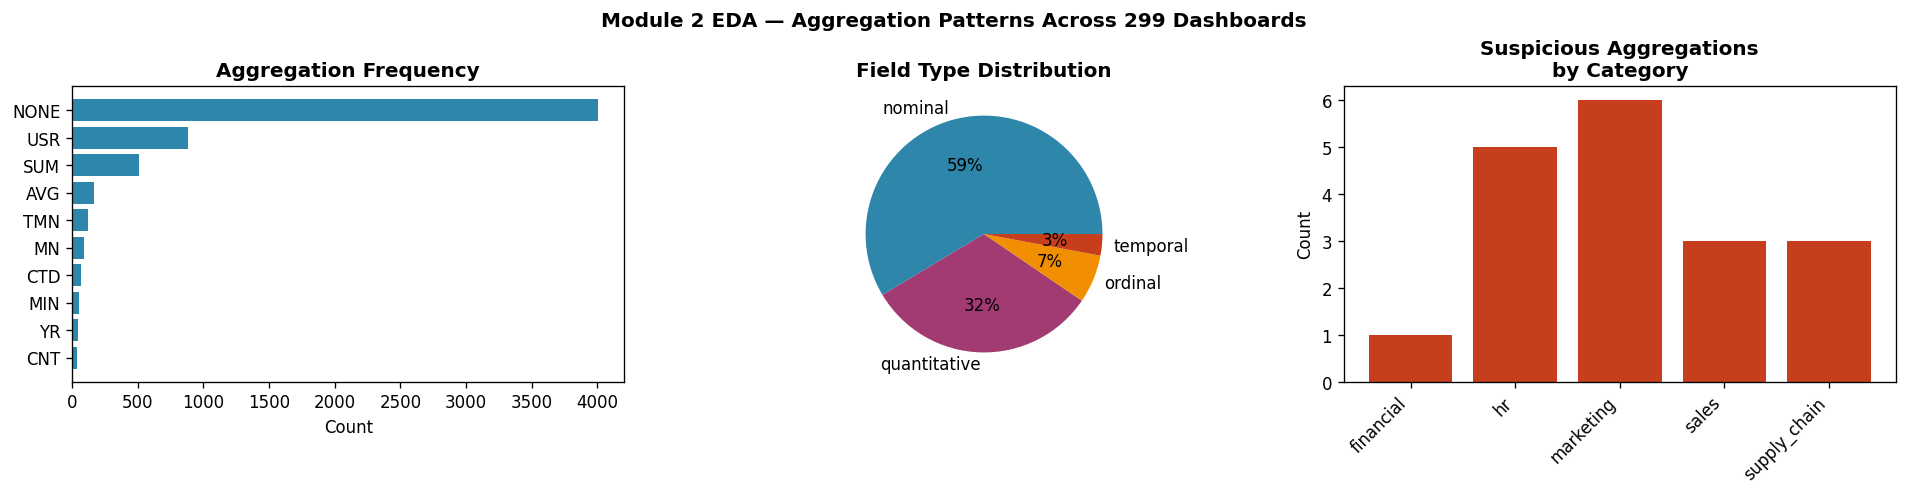


EDA complete.


In [28]:
# ── Plots ─────────────────────────────────────────────────────────────────────
if PLOT:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Plot 1 - aggregation frequency
    ax = axes[0]
    items = agg_counts.most_common(10)
    ax.barh([a for a,_ in items[::-1]], [c for _,c in items[::-1]],
            color="#2E86AB")
    ax.set_title("Aggregation Frequency", fontweight="bold")
    ax.set_xlabel("Count")

    # Plot 2 - field type distribution
    ax = axes[1]
    ft_counts = Counter(r["field_type"] for r in eda_records)
    ax.pie(ft_counts.values(), labels=ft_counts.keys(), autopct="%1.0f%%",
           colors=["#2E86AB","#A23B72","#F18F01","#C73E1D","#888"])
    ax.set_title("Field Type Distribution", fontweight="bold")

    # Plot 3 - suspicious by category
    ax = axes[2]
    if suspicious:
        cat_sus = Counter(s["category"] for s in suspicious)
        ax.bar(cat_sus.keys(), cat_sus.values(), color="#C73E1D")
        ax.set_title("Suspicious Aggregations\nby Category", fontweight="bold")
        ax.set_ylabel("Count")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    else:
        ax.text(0.5,0.5,"No suspicious combinations\nfound",
                ha="center",va="center",transform=ax.transAxes)
        ax.set_title("Suspicious by Category", fontweight="bold")

    plt.tight_layout()
    plt.suptitle("Module 2 EDA — Aggregation Patterns Across 299 Dashboards",
                 y=1.02, fontweight="bold", fontsize=12)
    plt.show()

print("\nEDA complete.")


### Cell 10 — Aggregation Correctness Rules (M1–M9)

This is where the EDA above turns into actual, checkable rules. The structure mirrors Module 1 closely on purpose: a small dataclass to hold one flagged issue (10a), one function containing all 9 rules with each rule commented and cited individually (10b), then a cell that runs the rules across every chart and prints a summary (10c). Keeping the same structure as Module 1 throughout this thesis - rather than inventing a different pattern for each module - makes it easier for a reader (or an examiner) to compare the two modules' rigor side by side.

#### 10a — `AggIssue` record

Same idea as Module 1's `Issue` dataclass, just with a couple of extra fields (`field_name`, `aggregation`, `field_type`, `shelf`) since aggregation issues are about one specific field, not the whole chart.

In [29]:
# ── Cell 10: Module 2 — Aggregation Correctness Rules ───────────────────────
from dataclasses import dataclass as _dc

@_dc
class AggIssue:
    dashboard_id : str
    category     : str
    sheet_name   : str
    mark_type    : str
    rule_id      : str
    severity     : str   # ERROR or WARNING
    problem      : str
    fix          : str
    field_name   : str
    aggregation  : str
    field_type   : str
    shelf        : str


#### 10b — `check_aggregation()`: Rules M1-M9

M1-M2 used to live in Module 1 - moved them here since they're really about aggregation, not chart type. M3-M9 are the new logic-based checks, based on VizLinter `hard.lp` and the SAGE semantic-validity idea (Cho & Fariha 2026). Keeping all nine in one function (like Module 1's `check()`) since they share the same `flag()` closure - each rule is commented and self-contained, so it still reads top to bottom.

In [30]:
def check_aggregation(did, cat, sheet_name, mark, rows, cols, colors, sizes):
    """
    these are my module 2 rules for checking aggregations.
    rules m1-m2 used to live in module 1, moved them here since they are
    really about aggregation, not chart type.
    rules m3-m9 are the new logic-based checks i added.
    based on vizlinter hard.lp and the sage semantic validity idea
    (cho and fariha 2026).
    """
    issues   = []
    all_f    = rows + cols + colors + sizes
    axis_f   = rows + cols

    def flag(rule_id, sev, problem, fix, f):
        issues.append(AggIssue(
            did, cat, sheet_name, mark, rule_id, sev,
            problem, fix,
            f.field_name, f.aggregation or "none",
            f.vl_type, f.shelf))

    # ── M1: SUM/AVG on nominal field ────────────────────────────────────────
    # VizLinter enc_type_valid_1 — moved from Module 1
    for f in all_f:
        if (f.aggregation and f.aggregation.lower() in NUMERIC_AGGS
                and f.vl_type == "nominal"):
            flag("M1_numeric_agg_on_nominal", "ERROR",
                 f"Field '{f.field_name}' is a text/nominal field but "
                 f"{f.aggregation.upper()} is applied. Cannot aggregate "
                 f"text mathematically.",
                 "Use COUNT or COUNT DISTINCT instead, or use a numeric field.",
                 f)

    # ── M2: SUM/AVG on temporal field ───────────────────────────────────────
    # VizLinter aggregate_t_valid — moved from Module 1
    for f in all_f:
        if (f.vl_type == "temporal" and f.aggregation
                and f.aggregation.lower() in {"sum","avg","median","stdev","var"}):
            flag("M2_numeric_agg_on_temporal", "ERROR",
                 f"Date/time field '{f.field_name}' has "
                 f"{f.aggregation.upper()} aggregation. "
                 f"Dates cannot be summed or averaged meaningfully.",
                 "Use MIN or MAX to show earliest/latest, or use as a "
                 "dimension with no aggregation.",
                 f)

    # ── M3: Date truncation on non-temporal field ────────────────────────────
    # Extension of VizLinter aggregate_t_valid
    for f in all_f:
        if (f.aggregation and f.aggregation.lower() in DATE_PREFIXES
                and f.vl_type in ("nominal","ordinal")):
            flag("M3_date_trunc_on_nontemporal", "ERROR",
                 f"Field '{f.field_name}' is typed as {f.vl_type} but "
                 f"a date truncation ({f.aggregation.upper()}) is applied. "
                 f"Date parts only make sense on temporal fields.",
                 "Check that the field is set to Date type in Tableau, "
                 "or remove the date truncation.",
                 f)

    # ── M4: Numeric aggregation on ordinal field ─────────────────────────────
    # Extension of VizLinter enc_type_valid_1 to ordinal
    for f in all_f:
        if (f.aggregation and f.aggregation.lower() in {"sum","avg","stdev","var"}
                and f.vl_type == "ordinal"):
            flag("M4_numeric_agg_on_ordinal", "WARNING",
                 f"Field '{f.field_name}' is ordinal (ordered category) "
                 f"but {f.aggregation.upper()} is applied. Numeric aggregation "
                 f"on ordinal data can produce misleading results.",
                 "Use COUNT or MEDIAN, or verify the field should be "
                 "quantitative.",
                 f)

    # ── M5: COUNT DISTINCT on a quantitative measure ─────────────────────────
    # SAGE-inspired: semantically invalid aggregation choice
    for f in all_f:
        if (f.aggregation and f.aggregation.lower() == "cntd"
                and f.vl_type == "quantitative"):
            flag("M5_cntd_on_measure", "WARNING",
                 f"COUNT DISTINCT is applied to '{f.field_name}' which "
                 f"is a numeric measure. Counting distinct values of a "
                 f"continuous field is rarely meaningful.",
                 "Use SUM or AVG to aggregate the measure value, or use "
                 "COUNT DISTINCT on a dimension instead.",
                 f)

    # ── M6: Pie chart not using Percent of Total ─────────────────────────────
    # Chart-context logic rule
    if mark == "pie":
        has_measure = any(f.vl_type == "quantitative" for f in all_f)
        has_pcto    = any("pcto" in (f.__dict__.get("raw_agg","") or "").lower()
                         for f in all_f)
        if has_measure and not has_pcto:
            for f in all_f:
                if f.vl_type == "quantitative":
                    flag("M6_pie_without_pcto", "WARNING",
                         f"Pie chart uses {f.aggregation or 'no'} aggregation "
                         f"on '{f.field_name}' without Percent of Total. "
                         f"Pie slices represent proportions — raw values make "
                         f"the chart harder to interpret accurately.",
                         "Switch the aggregation to Quick Table Calculation "
                         "→ Percent of Total.",
                         f)
                    break

    # ── M7: Aggregated measure only on Color, no measure on axes ─────────────
    # Shelf-logic rule
    axis_has_measure = any(f.vl_type == "quantitative" and f.aggregation
                           for f in axis_f)
    color_has_agg    = any(f.aggregation and
                           f.aggregation.lower() in NUMERIC_AGGS
                           for f in colors)
    if color_has_agg and not axis_has_measure and mark in ("bar","line","area"):
        for f in colors:
            if f.aggregation and f.aggregation.lower() in NUMERIC_AGGS:
                flag("M7_measure_only_on_color", "WARNING",
                     f"'{f.field_name}' ({f.aggregation.upper()}) is only "
                     f"on the Color shelf with no numeric measure on Rows/Cols. "
                     f"The chart has no quantitative axis to encode magnitude.",
                     "Move the measure to Rows or Columns to give the chart "
                     "a meaningful numeric axis.",
                     f)
                break

    # ── M8: SUM on identifier-style field ────────────────────────────────────
    # SAGE semantic validity — deterministic implementation via field name
    for f in all_f:
        if (f.aggregation and f.aggregation.lower() == "sum"
                and f.vl_type == "quantitative"
                and any(h in f.field_name.lower() for h in ID_HINTS)):
            flag("M8_sum_on_identifier", "WARNING",
                 f"SUM is applied to '{f.field_name}' which appears to "
                 f"be an identifier or code field. Summing identifiers "
                 f"produces a meaningless total.",
                 "Use COUNT or COUNT DISTINCT to count records, "
                 "not SUM.",
                 f)

    # ── M9: SUM on ratio/percentage field ────────────────────────────────────
    # SAGE semantic validity — ratio fields are non-additive
    for f in all_f:
        if (f.aggregation and f.aggregation.lower() == "sum"
                and f.vl_type == "quantitative"
                and any(h in f.field_name.lower() for h in RATIO_HINTS)):
            flag("M9_sum_on_ratio_field", "WARNING",
                 f"SUM is applied to '{f.field_name}' which appears to "
                 f"be a ratio or percentage field. Summing ratios does not "
                 f"produce a meaningful result.",
                 "Use AVG instead of SUM for ratio and percentage fields.",
                 f)

    return issues


#### 10c — Run the rules + print the summary

Runs `check_aggregation()` against every sheet `get_m2_sheets()` produced, collects every issue into `m2_issues`, then prints the same kind of breakdown Module 1 produces: overall correct/flagged counts, a breakdown by which specific rule (M1-M9) fired most often, and a breakdown by business category. This is the cell that produces the 90.0%/10.0% headline split for this module.

In [31]:
# ── Run rules on all active sheets ──────────────────────────────────────────
print("Running Module 2 aggregation correctness rules...")
m2_issues = []
for did, cat, sname, mark, rows, cols, colors, sizes in m2_sheets:
    iss = check_aggregation(did, cat, sname, mark, rows, cols, colors, sizes)
    m2_issues.extend(iss)

# ── Summary ──────────────────────────────────────────────────────────────────
flagged_sheets = set((i.dashboard_id, i.sheet_name) for i in m2_issues)
clean_count    = len(m2_sheets) - len(flagged_sheets)

print("\n" + "="*60)
print("  MODULE 2 — AGGREGATION CORRECTNESS RESULTS")
print("="*60)
print(f"  Sheets checked          : {len(m2_sheets)}")
print(f"  Correct (no issues)     : {clean_count}  "
      f"({clean_count/max(len(m2_sheets),1)*100:.1f}%)")
print(f"  With issues             : {len(flagged_sheets)}  "
      f"({len(flagged_sheets)/max(len(m2_sheets),1)*100:.1f}%)")
print(f"  Total issues            : {len(m2_issues)}")
print(f"    Errors                : {sum(1 for i in m2_issues if i.severity=='ERROR')}")
print(f"    Warnings              : {sum(1 for i in m2_issues if i.severity=='WARNING')}")

print("\n  Issues by rule:")
for rule, cnt in Counter(i.rule_id for i in m2_issues).most_common():
    print(f"    {cnt:4d}  {rule}")

print("\n  Issues by category:")
for cat, cnt in Counter(i.category for i in m2_issues).most_common():
    print(f"    {cnt:4d}  {cat}")
print("="*60)


Running Module 2 aggregation correctness rules...

  MODULE 2 — AGGREGATION CORRECTNESS RESULTS
  Sheets checked          : 1654
  Correct (no issues)     : 1489  (90.0%)
  With issues             : 165  (10.0%)
  Total issues            : 180
    Errors                : 0
    Warnings              : 180

  Issues by rule:
     114  M6_pie_without_pcto
      39  M9_sum_on_ratio_field
      18  M4_numeric_agg_on_ordinal
       9  M8_sum_on_identifier

  Issues by category:
      45  hr
      44  operations
      23  marketing
      21  sales
      16  supply_chain
      11  financial
      11  healthcare
       9  education


### Cell 11 — Feature Extraction + ML Model

Turns every chart into a fixed-length numeric feature vector (Cell 11b) and trains two models on it - a Decision Tree (11c) and a Random Forest (11d) - both predicting the *same label the rules above already assigned*, not some separate ground truth. As explained in the Module 2 Summary above, the purpose of this isn't to find a "more accurate" classifier than the rules; it's to check whether the rules' verdicts correspond to a real, learnable pattern in the chart structure, as a sanity check on the rules themselves rather than a replacement for them.

#### 11a — Guard check + build the feature matrix

Bails out early with a clear message if sklearn isn't installed or if Module 2's EDA/rules cells haven't been run yet (so `m2_sheets` is empty). Otherwise turns every chart into a fixed-length feature vector - one flag per aggregation type / field type seen, plus a few derived flags like `pie_missing_pcto` - and labels it `correct`/`flagged` based on whether the rules above found any issue.

In [32]:
if not SK:
    print("sklearn isn't installed, run pip install scikit-learn first")
elif not m2_sheets:
    print("got nothing back from get_m2_sheets, can't train on empty data")
    print("This usually means Cell 9/10 (EDA/rules) ran on an empty m2_sheets list.")
    print("Re-run the Module 2 cells in order, starting from the imports cell, "
          "and check the 'Re-parsed N active sheets' message above is not 0.")


#### 11b — Feature extraction function + build X, y

Note: this is split out of the original `if/elif/else:` guard above for readability - if the guard above printed an error, this cell (and the ones after it) will raise a `NameError` rather than silently doing nothing, which is actually more obvious when something's wrong than the original silent skip.

In [33]:
# ── Feature extraction ───────────────────────────────────────────────────
FEATURE_COLS = [
    "has_sum","has_avg","has_cnt","has_cntd","has_pcto",
    "has_min_max","has_usr","has_date_trunc","has_no_agg",
    "has_quantitative","has_nominal","has_ordinal","has_temporal",
    "agg_on_color_only","measure_on_axis",
    "n_measures","n_dimensions",
    "pie_uses_pcto","pie_missing_pcto",
    "cntd_on_measure","sum_on_ordinal","avg_on_ordinal",
    "date_trunc_on_nontemporal","sum_on_nominal","sum_on_temporal",
    "agg_mismatch_axes",
]

def extract_features(did, cat, sname, mark, rows, cols, colors, sizes, issues):
    all_f  = rows + cols + colors + sizes
    axis_f = rows + cols
    ft = {c: 0 for c in FEATURE_COLS}
    ft.update({"dashboard_id":did,"category":cat,
               "sheet_name":sname,"mark_type":mark,"label":"correct"})

    for f in all_f:
        agg     = (f.aggregation or "").lower()
        raw_agg = (f.__dict__.get("raw_agg","") or "").lower()
        if agg == "sum":                  ft["has_sum"]  = 1
        elif agg == "avg":                ft["has_avg"]  = 1
        elif agg == "cnt":                ft["has_cnt"]  = 1
        elif agg == "cntd":               ft["has_cntd"] = 1
        elif "pcto" in raw_agg:           ft["has_pcto"] = 1
        elif agg in {"min","max"}:        ft["has_min_max"] = 1
        elif agg == "usr":                ft["has_usr"]  = 1
        elif agg in DATE_PREFIXES:        ft["has_date_trunc"] = 1
        elif not agg:                     ft["has_no_agg"] = 1

        if f.vl_type == "quantitative":   ft["has_quantitative"] = 1
        elif f.vl_type == "nominal":      ft["has_nominal"]  = 1
        elif f.vl_type == "ordinal":      ft["has_ordinal"]  = 1
        elif f.vl_type == "temporal":     ft["has_temporal"] = 1

        if f.vl_type == "quantitative" and f.aggregation:
            ft["n_measures"] += 1
        elif not f.aggregation:
            ft["n_dimensions"] += 1

    ft["measure_on_axis"] = int(any(
        f.vl_type=="quantitative" and f.aggregation for f in axis_f))
    ft["agg_on_color_only"] = int(
        any(f.aggregation and f.aggregation.lower() in NUMERIC_AGGS
            for f in colors) and not ft["measure_on_axis"])

    if mark == "pie":
        ft["pie_uses_pcto"]    = int(any(
            "pcto" in (f.__dict__.get("raw_agg","") or "") for f in all_f))
        ft["pie_missing_pcto"] = int(
            ft["has_quantitative"] and not ft["pie_uses_pcto"])

    ft["cntd_on_measure"] = int(any(
        (f.aggregation or "").lower()=="cntd" and f.vl_type=="quantitative"
        for f in all_f))
    ft["sum_on_ordinal"]  = int(any(
        (f.aggregation or "").lower()=="sum" and f.vl_type=="ordinal"
        for f in all_f))
    ft["avg_on_ordinal"]  = int(any(
        (f.aggregation or "").lower()=="avg" and f.vl_type=="ordinal"
        for f in all_f))
    ft["date_trunc_on_nontemporal"] = int(any(
        (f.aggregation or "").lower() in DATE_PREFIXES
        and f.vl_type in ("nominal","ordinal") for f in all_f))
    ft["sum_on_nominal"]  = int(any(
        (f.aggregation or "").lower()=="sum" and f.vl_type=="nominal"
        for f in all_f))
    ft["sum_on_temporal"] = int(any(
        (f.aggregation or "").lower() in {"sum","avg"}
        and f.vl_type=="temporal" for f in all_f))

    axis_aggs    = {(f.aggregation or "").lower() for f in axis_f if f.aggregation}
    ft["agg_mismatch_axes"] = int(
        bool(axis_aggs & NUMERIC_AGGS) and bool(axis_aggs & {"cnt","cntd"}))

    ft["label"] = "flagged" if issues else "correct"
    return ft

# ── Build feature matrix ─────────────────────────────────────────────────
issue_map = {}
for iss in m2_issues:
    issue_map.setdefault((iss.dashboard_id, iss.sheet_name), []).append(iss)

feature_rows = []
for did, cat, sname, mark, rows, cols, colors, sizes in m2_sheets:
    iss  = issue_map.get((did, sname), [])
    feat = extract_features(did, cat, sname, mark,
                            rows, cols, colors, sizes, iss)
    feature_rows.append(feat)

print(f"Feature matrix: {len(feature_rows)} charts × {len(FEATURE_COLS)} features")
n_flagged = sum(1 for r in feature_rows if r["label"]=="flagged")
n_correct = sum(1 for r in feature_rows if r["label"]=="correct")
print(f"Class balance : correct={n_correct}, flagged={n_flagged}")

# ── Build X, y ───────────────────────────────────────────────────────────
mark_enc = LabelEncoder()
mark_enc.fit([r["mark_type"] for r in feature_rows])

def build_Xy(rows):
    X, y = [], []
    for r in rows:
        vec = [r[c] for c in FEATURE_COLS]
        vec.append(mark_enc.transform([r["mark_type"]])[0])
        X.append(vec); y.append(1 if r["label"]=="flagged" else 0)
    return np.array(X), np.array(y)

X, y = build_Xy(feature_rows)
feat_names = FEATURE_COLS + ["mark_type_encoded"]


Feature matrix: 1654 charts × 26 features
Class balance : correct=1489, flagged=165


#### 11c — Decision Tree (depth=4, fully explainable)

Trained directly on the rule labels. Capped at depth 4 so the printed rule structure stays human-readable.

In [34]:
# ── Decision Tree ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  DECISION TREE (depth=4, fully explainable)")
print("="*60)
dt = DecisionTreeClassifier(max_depth=4, random_state=42,
                             class_weight="balanced")
dt.fit(X, y)
print(export_text(dt, feature_names=feat_names))



  DECISION TREE (depth=4, fully explainable)
|--- pie_missing_pcto <= 0.50
|   |--- has_sum <= 0.50
|   |   |--- avg_on_ordinal <= 0.50
|   |   |   |--- n_dimensions <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- n_dimensions >  0.50
|   |   |   |   |--- class: 0
|   |   |--- avg_on_ordinal >  0.50
|   |   |   |--- class: 1
|   |--- has_sum >  0.50
|   |   |--- sum_on_ordinal <= 0.50
|   |   |   |--- has_usr <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_usr >  0.50
|   |   |   |   |--- class: 0
|   |   |--- sum_on_ordinal >  0.50
|   |   |   |--- class: 1
|--- pie_missing_pcto >  0.50
|   |--- class: 1



#### 11d — Random Forest (100 trees)

Same labels, but an ensemble - cross-validated, with Cohen's Kappa against the rule labels printed directly. This is the model whose agreement with the rules ends up in the thesis (96.5%).

In [35]:
# ── Random Forest ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  RANDOM FOREST (100 trees)")
print("="*60)
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight="balanced")

if n_flagged >= 2:
    cv   = StratifiedKFold(n_splits=min(5, n_flagged), shuffle=True,
                           random_state=42)
    y_cv = cross_val_predict(rf, X, y, cv=cv)
    print("\n  Cross-validation results:")
    print(classification_report(y, y_cv,
          target_names=["correct","flagged"], zero_division=0))
    print(f"  Cohen Kappa (Rules vs RF-CV): "
          f"{cohen_kappa_score(y, y_cv):.3f}")
else:
    print("  (Too few flagged examples for cross-validation — "
          "run on full 299 dashboards for meaningful CV results)")

rf.fit(X, y)
y_pred_rf = rf.predict(X)
print("\n  Training accuracy (in-sample):")
print(classification_report(y, y_pred_rf,
      target_names=["correct","flagged"], zero_division=0))



  RANDOM FOREST (100 trees)

  Cross-validation results:
              precision    recall  f1-score   support

     correct       0.98      0.97      0.98      1489
     flagged       0.75      0.85      0.80       165

    accuracy                           0.96      1654
   macro avg       0.87      0.91      0.89      1654
weighted avg       0.96      0.96      0.96      1654

  Cohen Kappa (Rules vs RF-CV): 0.774

  Training accuracy (in-sample):
              precision    recall  f1-score   support

     correct       0.99      0.97      0.98      1489
     flagged       0.76      0.95      0.84       165

    accuracy                           0.96      1654
   macro avg       0.88      0.96      0.91      1654
weighted avg       0.97      0.96      0.97      1654



#### 11e — Feature importance + plot

Prints which structural features the Random Forest actually relied on most when reproducing the rules' verdicts, and plots both that feature-importance ranking and a confusion matrix from the 5-fold cross-validation run in the previous cell. If a feature near the top of this list lines up with what one of the M1-M9 rules explicitly checks for (e.g. `has_sum` or `pie_missing_pcto`), that's a useful, concrete confirmation that the model is picking up on the same signal the rules were designed around - not some unrelated correlation.


  Top features by importance (Random Forest):
    pie_missing_pcto                    0.2850
    mark_type_encoded                   0.1961
    n_dimensions                        0.1163
    has_sum                             0.1163
    sum_on_ordinal                      0.0592
    n_measures                          0.0590
    measure_on_axis                     0.0431
    has_usr                             0.0344
    has_quantitative                    0.0229
    has_ordinal                         0.0189
    has_avg                             0.0108
    has_no_agg                          0.0101


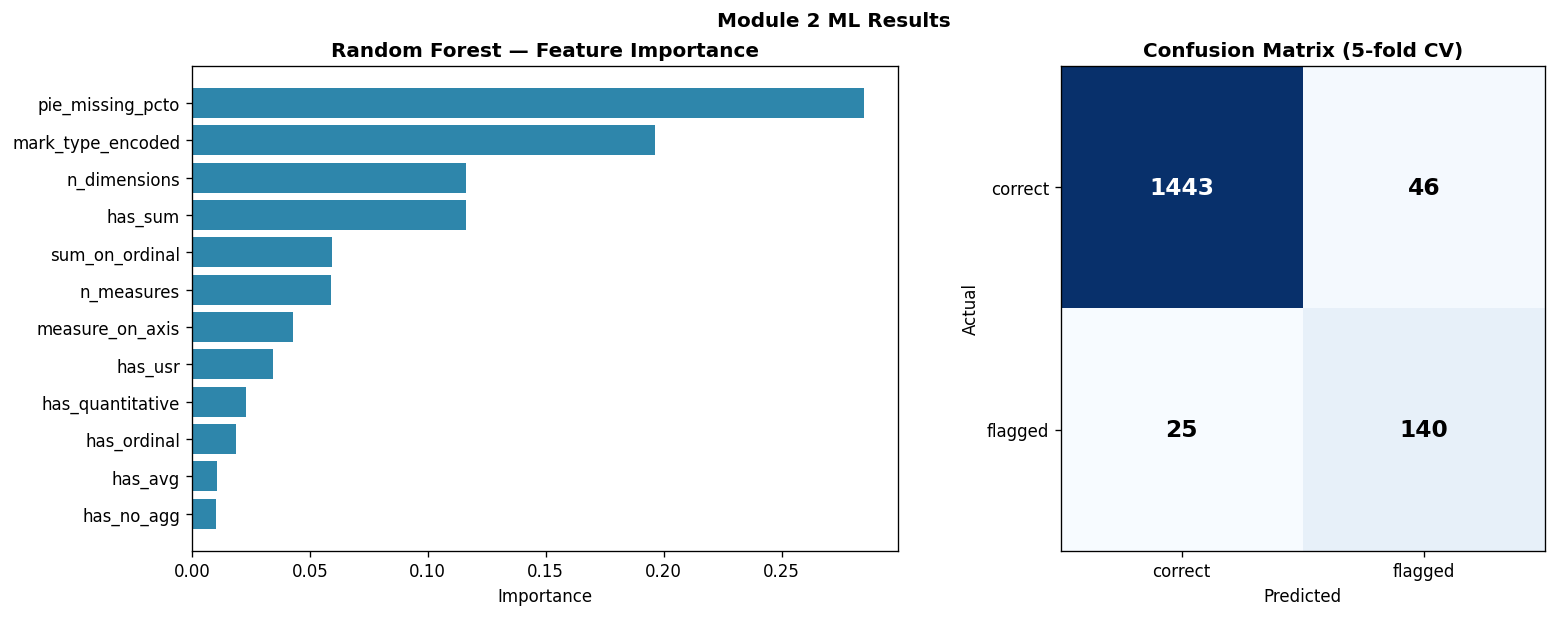


Module 2 ML complete.


In [36]:
# ── Feature importance ────────────────────────────────────────────────────
print("\n  Top features by importance (Random Forest):")
imp = rf.feature_importances_
for i in np.argsort(imp)[::-1][:12]:
    if imp[i] > 0.005:
        print(f"    {feat_names[i]:<35} {imp[i]:.4f}")

# ── Feature importance plot ───────────────────────────────────────────────
if PLOT:
    top_idx = np.argsort(imp)[::-1][:12]
    top_imp = imp[top_idx]
    top_nms = [feat_names[i] for i in top_idx]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(top_nms[::-1], top_imp[::-1], color="#2E86AB")
    axes[0].set_title("Random Forest — Feature Importance",fontweight="bold")
    axes[0].set_xlabel("Importance")

    if n_flagged >= 2:
        cm = confusion_matrix(y, y_cv)
        im = axes[1].imshow(cm, cmap="Blues")
        axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
        axes[1].set_xticklabels(["correct","flagged"])
        axes[1].set_yticklabels(["correct","flagged"])
        axes[1].set_title("Confusion Matrix (5-fold CV)", fontweight="bold")
        axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
        for i in range(2):
            for j in range(2):
                axes[1].text(j, i, str(cm[i,j]), ha="center",
                             va="center", fontsize=14, fontweight="bold",
                             color="white" if cm[i,j]>cm.max()/2 else "black")
    else:
        axes[1].text(0.5,0.5,
            "Run on full 299 dashboards\nfor confusion matrix",
            ha="center",va="center",transform=axes[1].transAxes)
        axes[1].set_title("Confusion Matrix", fontweight="bold")

    plt.tight_layout()
    plt.suptitle("Module 2 ML Results", y=1.02,
                 fontweight="bold", fontsize=12)
    plt.show()

print("\nModule 2 ML complete.")


### Cell 12 — Rules vs ML Comparison + CSV Export

Lines the Random Forest's predictions up against the rules' original verdicts, chart by chart, prints where they agree and disagree, then saves the full Module 2 result set to a CSV for the dissertation's results chapter. The disagreement cases specifically (12a) are worth reading individually rather than just looking at the aggregate 96.5% figure - they're the charts where the rules and a blind structural model reached different conclusions, and looking at *why* they disagree is more informative than the percentage on its own.

#### 12a — Print the per-sheet Rules vs RF comparison table

Walks every chart and prints whether the rules and the Random Forest agree (`✓`) or disagree (`✗ DISAGREE`), then a running tally of total agreement/disagreement counts and percentages, followed by a closer look at every individual disagreement case. The disagreement list at the end is short enough (58 cases out of 1,654) to skim through directly, which is a useful sanity check beyond just trusting the headline 96.5% number.

In [37]:
# ── Cell 12: Module 2 — Rules vs ML Comparison + CSV Export ─────────────────
print("="*60)
print("  comparing rules against the ml model")
print("="*60)
print(f"  {'Sheet':<45} {'Rules':<10} {'RF':<10} {'Match'}")
print(f"  {'-'*72}")

agree = disagree = 0
disagree_list = []
for i, r in enumerate(feature_rows):
    rule_lbl = "FLAGGED" if r["label"]=="flagged" else "correct"
    rf_lbl   = "FLAGGED" if (SK and y_pred_rf[i]==1) else "correct"
    match    = "✓" if rule_lbl==rf_lbl else "✗ DISAGREE"
    if rule_lbl == rf_lbl: agree += 1
    else:
        disagree += 1
        disagree_list.append((r["sheet_name"], rule_lbl, rf_lbl))
    print(f"  {r['sheet_name'][:44]:<45} {rule_lbl:<10} {rf_lbl:<10} {match}")

total = agree + disagree
print(f"\n  Agreement : {agree}/{total} ({agree/max(total,1)*100:.1f}%)")
print(f"  Disagree  : {disagree}/{total} ({disagree/max(total,1)*100:.1f}%)")

if disagree_list:
    print(f"\n  Disagreements:")
    for sname, r_lbl, ml_lbl in disagree_list:
        print(f"    {sname[:50]}")
        print(f"      Rules: {r_lbl}  |  ML: {ml_lbl}")


  comparing rules against the ml model
  Sheet                                         Rules      RF         Match
  ------------------------------------------------------------------------
  Enrollment vs Out-of-School                   correct    correct    ✓
  Outlier Analysis                              correct    correct    ✓
  Trend Out-of-School Over Time                 correct    correct    ✓
  Bottom 3 Universities by Graduation Rate      correct    correct    ✓
  Bottom 5 States by Graduation Rate            correct    correct    ✓
  Relationship Between Federal Grant Aid and G  correct    correct    ✓
  Top 3 Universities by Graduation Rate         correct    correct    ✓
  Top 5 States by Graduation Rate               correct    correct    ✓
  public vs private                             correct    correct    ✓
  Bubble Map                                    correct    correct    ✓
  Enrollment Size vs Grad Rate                  correct    correct    ✓
  Financial Aid Br

#### 12b — Save the Module 2 results to CSV

Writes every chart's rule-based status, the specific rule(s) that fired (if any), and the field/aggregation/shelf details behind each issue out to `aggregation_correctness.csv`, then triggers a download. This is the file referenced in the dissertation's results tables for Module 2's headline numbers (90.0% correct / 10.0% flagged) and the per-rule breakdown.

In [38]:
# ── Save Module 2 CSV ────────────────────────────────────────────────────────
try:
    from google.colab import files as colab_files
    m2_csv = "aggregation_correctness.csv"
    with open(m2_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["dashboard_id","category","sheet_name","mark_type",
                    "status","rule_id","severity","problem","fix",
                    "field_name","aggregation","field_type","shelf",
                    "annotator_label","notes"])
        written = set()
        iss_map = {}
        for iss in m2_issues:
            iss_map.setdefault((iss.dashboard_id, iss.sheet_name), []).append(iss)
        for did, cat, sname, mark, *_ in m2_sheets:
            key  = (did, sname)
            isss = iss_map.get(key, [])
            if not isss:
                if key not in written:
                    w.writerow([did,cat,sname,mark,"Clean",
                                "","","","","","","","","",""])
                    written.add(key)
            else:
                for iss in isss:
                    w.writerow([iss.dashboard_id, iss.category,
                                iss.sheet_name, iss.mark_type, "Flagged",
                                iss.rule_id, iss.severity,
                                iss.problem, iss.fix,
                                iss.field_name, iss.aggregation,
                                iss.field_type, iss.shelf, "", ""])
    print(f"\nSaved: {m2_csv}")
    colab_files.download(m2_csv)
except Exception as e:
    print(f"CSV save: {e}")

print("\nModule 2 complete.")



Saved: aggregation_correctness.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Module 2 complete.


### Cell 13 — LLM Comparison (Rules vs ML vs LLM, via Claude)

Adds a third method to the Module 2 evaluation: a general-purpose LLM (Claude, via the Anthropic API) judges aggregation correctness from chart metadata, compared against the rule-based labels and Random Forest predictions computed above.

**Note:** an earlier version of this cell used Google's free-tier Gemini API. During testing, Gemini's free tier returned HTTP 429 (rate limit) errors on the majority of requests and intermittent HTTP 503 (service unavailable) errors, confirmed via Google AI Studio's own usage dashboard. This version uses the Anthropic API instead, which requires billing to be set up at console.anthropic.com (separate from a Claude Pro/claude.ai subscription, which does not include API access). Cost for the default sample of 30 short prompts is well under $0.10.

**Limitation, stated upfront:** most field names in this dataset are opaque Tableau calculation IDs (e.g. `Calculation_197736183839531031`), carrying no semantic meaning. The LLM can only reason about structural properties - mark type, aggregation function, field type, shelf placement - not what a field represents in the real world.

#### 13a — Setup: API key + config

This needs an Anthropic API key entered interactively (`getpass`), so this cell won't run unattended - it'll pause and wait for input.

In [39]:
# ── Cell 13: Module 2 — LLM Comparison (Rules vs ML vs LLM, via Claude) ─────
import getpass, time, random, re as _re2

LLM_SAMPLE_SIZE = 100    # went up from 30 to 100 here since the 30-sample run worked fine and fast
LLM_MODEL       = "claude-sonnet-4-6"
RANDOM_SEED     = 42
REQUEST_DELAY_SECONDS = 1.0   # Claude's paid tier has much higher rate limits than Gemini's free tier

try:
    import anthropic
    ANTHROPIC_SDK = True
except ImportError:
    print("installing the anthropic sdk now...")
    import subprocess
    subprocess.run(["pip", "install", "anthropic", "-q"])
    import anthropic
    ANTHROPIC_SDK = True

print("Get your Anthropic API key from https://console.anthropic.com")
print("(requires billing to be set up - this is a separate account from")
print(" Claude Pro/claude.ai, which does not include API access)\n")
api_key = getpass.getpass("Enter your Anthropic API key (input is hidden): ")
client = anthropic.Anthropic(api_key=api_key)


installing the anthropic sdk now...
Get your Anthropic API key from https://console.anthropic.com
(requires billing to be set up - this is a separate account from
 Claude Pro/claude.ai, which does not include API access)

Enter your Anthropic API key (input is hidden): ··········


#### 13b — Build a stratified sample (half flagged, half correct) and re-attach each chart's fields

Sending all 1,654 charts to the Claude API would work but costs time and money unnecessarily, so this draws a smaller stratified sample instead - half rule-flagged, half rule-correct, where possible - using a fixed random seed (42) so the sample is reproducible if this cell is re-run. It then re-attaches each sampled chart's actual field list (mark type, aggregations, shelves) from `m2_sheets`, since the LLM needs that structural detail to make a judgement, not just the chart's name.

In [40]:
# ── Build a stratified sample: half flagged, half correct (where possible) ──
random.seed(RANDOM_SEED)
flagged_rows  = [r for r in feature_rows if r["label"] == "flagged"]
correct_rows  = [r for r in feature_rows if r["label"] == "correct"]
n_each = LLM_SAMPLE_SIZE // 2
sample_flagged = random.sample(flagged_rows, min(n_each, len(flagged_rows)))
sample_correct = random.sample(correct_rows, min(LLM_SAMPLE_SIZE - len(sample_flagged), len(correct_rows)))
llm_sample = sample_flagged + sample_correct
random.shuffle(llm_sample)

print(f"Sampling {len(llm_sample)} charts for LLM comparison "
      f"({len(sample_flagged)} rule-flagged, {len(sample_correct)} rule-correct)")
print(f"Estimated time: ~{len(llm_sample) * REQUEST_DELAY_SECONDS / 60:.1f} minutes")

# ── Re-attach the original field list for each sampled chart ────────────────
sheet_field_map = {}
for did, cat, sname, mark, rows, cols, colors, sizes in m2_sheets:
    sheet_field_map[(did, sname)] = (mark, rows + cols + colors + sizes)


Sampling 100 charts for LLM comparison (50 rule-flagged, 50 rule-correct)
Estimated time: ~1.7 minutes


#### 13c — `build_prompt()` — turn a chart's fields into a prompt for Claude

Formats one chart's mark type and field list into a plain-text prompt asking Claude to judge whether each field's aggregation is semantically appropriate, and to respond in a fixed `VERDICT: / REASON:` format that's easy to parse reliably afterwards. The prompt deliberately lists the same kind of issues the M1-M9 rules check for (numeric aggregation on text fields, SUM on dates, pie charts without Percent of Total, etc.) in plain language, without ever mentioning the rules themselves or what they concluded - keeping the LLM's judgement genuinely blind to the rule-based labels.

In [41]:
def build_prompt(mark, fields):
    if not fields:
        fields_desc = "  (no fields on any shelf)"
    else:
        fields_desc = "\n".join(
            f"  - Field: '{f.field_name}', Aggregation: "
            f"{(f.aggregation or 'none').upper()}, Type: {f.vl_type}, "
            f"Shelf: {f.shelf}"
            for f in fields
        )
    return f"""You are reviewing a Tableau chart for aggregation correctness.

Chart mark type: {mark}
Fields used:
{fields_desc}

Question: Is the aggregation function applied to each field semantically
and structurally appropriate, given the field's data type and the chart's
mark type? Consider issues such as:
- Numeric aggregations (SUM, AVG) applied to text/categorical fields
- SUM or AVG applied to date/time fields
- COUNT DISTINCT applied to a continuous numeric measure
- Pie charts using raw values instead of Percent of Total
- Aggregations applied to identifier or ratio/percentage fields

Respond in exactly this format, nothing else:
VERDICT: <CORRECT or FLAGGED>
REASON: <one sentence explanation>"""


#### 13d — `call_llm()` — the actual API call, with retry logic

Always returns a `(verdict, reason)` tuple, even on total failure - never falls through to an implicit `None`, which was a real bug in an earlier version of this cell.

In [42]:
def call_llm(prompt, retries=4):
    # Same defensive pattern as the Gemini version: ALWAYS return a tuple,
    # never fall through to an implicit None, regardless of how the retry
    # loop exits.
    last_error = "Unknown error"
    for attempt in range(retries):
        is_last_attempt = (attempt == retries - 1)
        try:
            resp = client.messages.create(
                model=LLM_MODEL,
                max_tokens=150,
                messages=[{"role": "user", "content": prompt}],
            )
            text = resp.content[0].text if resp.content else ""
            verdict_match = _re2.search(r"\**VERDICT\**:?\s*\**\s*(CORRECT|FLAGGED)",
                                         text, _re2.IGNORECASE)
            reason_match  = _re2.search(r"\**REASON\**:?\s*\**\s*(.+)",
                                         text, _re2.IGNORECASE)
            verdict = verdict_match.group(1).upper() if verdict_match else "UNPARSEABLE"
            reason  = reason_match.group(1).strip() if reason_match else text[:150]
            return verdict, reason
        except Exception as e:
            err_str = str(e)
            last_error = err_str[:150]
            is_rate_limit = ("429" in err_str or "rate_limit" in err_str.lower()
                             or "overloaded" in err_str.lower())

            if is_last_attempt:
                if is_rate_limit:
                    print(f"    Rate limit hit on final retry - giving up "
                          f"on this chart, moving to the next one.")
                return "ERROR", f"Failed after {retries} attempts: {last_error}"

            if is_rate_limit:
                wait = 15 * (attempt + 1)
                print(f"    Rate limit hit, waiting {wait}s before retry...")
                time.sleep(wait)
            else:
                time.sleep(2 ** attempt)

    return "ERROR", f"Failed after {retries} attempts: {last_error}"


#### 13e — Run the LLM over the sample

Sends every sampled chart's prompt to Claude one at a time, with a short delay between requests, and collects each response's verdict and reasoning into `llm_results`. A progress message prints every 10 charts so a long run doesn't look like it's stalled.

In [43]:
print("\nQuerying Claude...\n")

llm_results = []
for i, r in enumerate(llm_sample):
    key = (r["dashboard_id"], r["sheet_name"])
    mark, fields = sheet_field_map.get(key, (r["mark_type"], []))
    prompt = build_prompt(mark, fields)
    verdict, reason = call_llm(prompt)
    llm_results.append({**r, "llm_verdict": verdict, "llm_reason": reason})
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(llm_sample)} done")
    time.sleep(REQUEST_DELAY_SECONDS)

print(f"\nLLM querying complete: {len(llm_results)} charts evaluated")



Querying Claude...

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done

LLM querying complete: 100 charts evaluated


#### 13f — Rules vs RF vs LLM: 3-way comparison + Cohen's Kappa

Lines up all three judgements - rules, Random Forest, and Claude - side by side for every sampled chart, flags rows where any of the three disagree, then computes Cohen's Kappa for each pairwise comparison (Rules vs LLM, RF vs LLM, Rules vs RF on this particular subset). The Rules-vs-LLM and RF-vs-LLM Kappa values are the genuinely independent agreement numbers in this whole notebook, since the LLM never saw either the rule labels or the Random Forest's predictions before forming its own judgement.

In [44]:
# ── Compare Rules vs ML vs LLM on the sampled charts ─────────────────────────
print("\n" + "="*70)
print("  RULES vs ML vs LLM — 3-WAY COMPARISON")
print("="*70)

valid_results = [r for r in llm_results if r["llm_verdict"] in ("CORRECT", "FLAGGED")]
n_unparseable = len(llm_results) - len(valid_results)
if n_unparseable:
    print(f"  Note: {n_unparseable} LLM responses could not be parsed/failed and "
          f"are excluded from agreement statistics.\n")
    bad_examples = [r for r in llm_results
                    if r["llm_verdict"] not in ("CORRECT", "FLAGGED")][:5]
    print("  Example failure reasons (first 5, for diagnosis):")
    for r in bad_examples:
        print(f"    [{r['llm_verdict']}] {r['llm_reason'][:150]}")
    print()

if not valid_results:
    print("  ALL LLM CALLS FAILED - stopping before the comparison table.")
    print("  Common causes:")
    print("    - Wrong API key type was entered (must be an Anthropic key from")
    print("      https://console.anthropic.com, not a Gemini/OpenAI key)")
    print("    - Billing not yet set up on the Anthropic account")
    print("    - Rate limit exceeded (see error text above)")
    print("  No CSV will be written since there is no valid data to save.")

sample_idx_in_full = []
for r in valid_results:
    for idx, fr in enumerate(feature_rows):
        if (fr["dashboard_id"], fr["sheet_name"]) == (r["dashboard_id"], r["sheet_name"]):
            sample_idx_in_full.append(idx)
            break

rule_labels = [1 if valid_results[i]["label"]=="flagged" else 0
               for i in range(len(valid_results))]
llm_labels  = [1 if valid_results[i]["llm_verdict"]=="FLAGGED" else 0
               for i in range(len(valid_results))]
rf_labels   = [int(y_pred_rf[idx]) for idx in sample_idx_in_full]

print(f"  {'Sheet':<42} {'Rules':<10} {'RF':<10} {'LLM':<10}")
print(f"  {'-'*74}")
for r, rf_lbl, llm_lbl in zip(valid_results, rf_labels, llm_labels):
    rule_s = "FLAGGED" if r["label"]=="flagged" else "correct"
    rf_s   = "FLAGGED" if rf_lbl==1 else "correct"
    llm_s  = "FLAGGED" if llm_lbl==1 else "correct"
    marker = "" if rule_s==rf_s==llm_s else "  <-- disagreement"
    print(f"  {r['sheet_name'][:41]:<42} {rule_s:<10} {rf_s:<10} {llm_s:<10}{marker}")

if SK and len(valid_results) > 1:
    kappa_rules_llm = cohen_kappa_score(rule_labels, llm_labels)
    kappa_rf_llm    = cohen_kappa_score(rf_labels, llm_labels)
    kappa_rules_rf  = cohen_kappa_score(rule_labels, rf_labels)

    agree_rules_llm = sum(1 for a,b in zip(rule_labels, llm_labels) if a==b)
    agree_rf_llm    = sum(1 for a,b in zip(rf_labels, llm_labels) if a==b)
    n = len(valid_results)

    print("\n" + "="*70)
    print("  AGREEMENT SUMMARY (on this LLM-sampled subset)")
    print("="*70)
    print(f"  Rules vs LLM : {agree_rules_llm}/{n} agree "
          f"({agree_rules_llm/n*100:.1f}%)  |  Cohen's Kappa = {kappa_rules_llm:.3f}")
    print(f"  RF    vs LLM : {agree_rf_llm}/{n} agree "
          f"({agree_rf_llm/n*100:.1f}%)  |  Cohen's Kappa = {kappa_rf_llm:.3f}")
    print(f"  Rules vs RF  : (on this subset) Cohen's Kappa = {kappa_rules_rf:.3f}")

    print("\n  Interpretation guide (Landis & Koch, 1977):")
    print("    <0.00 poor | 0.00-0.20 slight | 0.21-0.40 fair |")
    print("    0.41-0.60 moderate | 0.61-0.80 substantial | 0.81-1.00 almost perfect")



  RULES vs ML vs LLM — 3-WAY COMPARISON
  Sheet                                      Rules      RF         LLM       
  --------------------------------------------------------------------------
  Total Clicks BAN                           correct    correct    FLAGGED     <-- disagreement
  State legend                               correct    correct    FLAGGED     <-- disagreement
  Segment                                    FLAGGED    FLAGGED    FLAGGED   
  by Gender                                  FLAGGED    FLAGGED    FLAGGED   
  Sheet 5                                    FLAGGED    FLAGGED    FLAGGED   
  Detail Sheet                               FLAGGED    FLAGGED    FLAGGED   
  avg daily capacity                         correct    correct    correct   
  Sheet 34                                   FLAGGED    FLAGGED    FLAGGED   
  Total Shares BAN                           FLAGGED    correct    FLAGGED     <-- disagreement
  top 5                                      cor

#### 13g — Save the LLM comparison to CSV

Writes the sampled charts' rule label, Random Forest label, and LLM verdict + reasoning out to `llm_comparison.csv` and triggers a download, so the 3-way comparison can be referenced directly in the dissertation without needing to re-run the API calls.

In [45]:
# ── Save LLM comparison results to CSV ───────────────────────────────────────
if valid_results:
    try:
        from google.colab import files as colab_files
        llm_csv = "llm_comparison.csv"
        with open(llm_csv, "w", newline="", encoding="utf-8") as f:
            w = csv.writer(f)
            w.writerow(["dashboard_id","sheet_name","mark_type","rule_label",
                        "rf_label","llm_verdict","llm_reason"])
            for r, rf_lbl in zip(valid_results, rf_labels):
                w.writerow([r["dashboard_id"], r["sheet_name"], r["mark_type"],
                            r["label"], "flagged" if rf_lbl==1 else "correct",
                            r["llm_verdict"], r["llm_reason"]])
        print(f"\nSaved: {llm_csv} ({len(valid_results)} rows)")
        colab_files.download(llm_csv)
    except Exception as e:
        print(f"CSV save: {e}")
else:
    print("\nNo CSV written - there were 0 valid LLM results to save.")
    print("Fix the issue above, then re-run this cell.")

print("\nLLM comparison complete.")



Saved: llm_comparison.csv (100 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


LLM comparison complete.


## Module 2 Summary — Aggregation Correctness

**What it is:** A second, independent set of 9 rules (M1-M9) that check whether the *aggregation function* applied to each field makes sense, given that field's data type and the chart's overall context. This targets a genuinely different category of mistake to Module 1: a chart's mark type can be perfectly correct - a bar chart really is the right choice for comparing a measure across categories - while the aggregation sitting on top of it is still semantically wrong, e.g. summing an identifier field, or a pie chart showing raw values instead of Percent of Total. Module 1 asks "is this the right kind of chart for this data shape?"; Module 2 asks "given that chart, is the number actually being computed in a way that means anything?" - the two checks are deliberately orthogonal so each can be evaluated and discussed on its own terms.

**Why we use it:** Rules M1 and M2 (numeric aggregation on a nominal/temporal field) actually started out living in Module 1, since they came from the same VizLinter source (`enc_type_valid_1`, `aggregate_t_valid`) as several Module 1 rules. They were moved here once it became clear they're conceptually about aggregation correctness, not chart-type correctness, and grouping them with the other seven aggregation rules made the module boundaries cleaner for both the code and the write-up. Rules M3-M9 are extensions and new logic-based checks built for this thesis specifically, partly inspired by SAGE's (Cho & Fariha, 2026) idea of semantic validity - the principle that an aggregation can be syntactically valid (Tableau will happily compute SUM of any numeric field) while still being semantically meaningless (summing a customer ID number produces a number, but not one that means anything). M8 and M9 operationalise that idea concretely: they flag SUM applied to a field whose *name* contains identifier-like or ratio-like keywords (`id`, `code`, `rate`, `pct`, etc.), since Tableau itself doesn't store "this field represents a ratio" as real, checkable metadata anywhere in the file - field-name pattern matching is the only practical signal available without a human manually annotating every one of the thousands of fields in this dataset.

**Implementation in code:** All 9 rules live inside `check_aggregation()` (Cell 10b above), following the same single-function structure as Module 1's `check()` so each rule stays self-contained and commented but shares one `flag()` closure:
- **M1** - SUM/AVG-family aggregation on a nominal (text) field
- **M2** - SUM/AVG-family aggregation on a temporal (date) field
- **M3** - a date-truncation aggregation (month/year/etc.) applied to a field that isn't actually temporal
- **M4** - numeric aggregation on an ordinal field (flagged as a WARNING rather than an ERROR, since ordinal data sits in a genuine grey area - summing a 1-5 satisfaction rating is debatable rather than definitively wrong)
- **M5** - COUNT DISTINCT applied to a continuous numeric measure, which is rarely a meaningful question to ask
- **M6** - a pie chart using a raw aggregated value instead of a Percent of Total quick table calculation
- **M7** - an aggregated measure sitting only on the Color shelf with no numeric value on either axis
- **M8** - SUM applied to a field that looks like an identifier, based on name-keyword matching
- **M9** - SUM applied to a field that looks like a ratio or percentage, based on name-keyword matching

On top of the rules, two ML models are trained (Cells 11c-11d, Decision Tree and Random Forest) - but it's important to be precise about what these models are actually doing, since it's easy to describe this in a way that overstates what's being measured. The models are trained on labels that come *directly from the rules themselves* (`label = "flagged" if issues else "correct"`), using only structural features as input (has_sum, field_type, mark_type, and so on) - the models never see the rule logic, only the raw chart structure. So a high agreement number here is not evidence that the rules are *correct* against some independent ground truth; there is no independent ground truth being compared against. What it *does* show is that the rules correspond to a consistent, learnable boundary in the structural data, rather than being a collection of arbitrary one-off heuristics that happen to fire on specific charts for no generalisable reason - if the rules were essentially noise, a model trained blind on structural features alone would struggle to reconstruct their verdicts. The one part of this module that genuinely is an independent check is Cell 13: having Claude (via the Anthropic API) judge a sample of charts from scratch, with no access to the rule labels and no awareness of which rule (if any) a chart might trigger.

**Results and Interpretation:**
- Of the 1,654 charts checked, **90.0% (1,489 charts) came back correct under the rules, 10.0% (165 charts) were flagged**, with 180 individual issues raised in total (all WARNING severity - none of the M1-M9 rules are configured as hard ERRORs, reflecting that aggregation mistakes are generally more debatable/context-dependent than the structural mistakes Module 1 catches).
- The single most common issue by a wide margin was **M6 (pie chart without Percent of Total)** at 114 instances - nearly two thirds of all flagged issues in this module - followed by M9 (SUM on a ratio-looking field, 39 instances) and M4 (numeric aggregation on an ordinal field, 18 instances). M5, M7, and M8 each accounted for under 10 instances, suggesting those particular mistakes are genuinely rare in this dataset rather than the rules being too narrow to catch them.
- By category, `hr` (45 flagged) and `operations` (44 flagged) had the most aggregation issues in absolute terms, though these are also two of the larger categories by chart count.
- **Rules vs Random Forest agreement: 96.5% (1,596/1,654)** - high enough to support the claim that the rules capture a consistent structural pattern, but again, this number measures *internal consistency between the rules and a model trained on the rules*, not independent correctness. This distinction matters enough that it's worth stating explicitly in the dissertation's limitations section rather than letting a reader assume "96.5% accuracy" means something it doesn't.
- The Claude LLM comparison (Cell 13) is the only genuinely independent check available in this module, since the LLM is given only the chart's structural metadata (mark type, fields, aggregations, shelves) and asked to judge correctness from scratch, with zero exposure to what the rules or the Random Forest concluded. *(Note: this cell requires an Anthropic API key entered interactively via `getpass`, and was not executed in the most recent full notebook run - if the cell above shows no output, it needs to be re-run with billing set up at console.anthropic.com before this comparison number exists.)*


## Module 3 — Axis and Scale Correctness

**Status: rule-based detection implemented, using real extracted data.**

The EDA below confirmed Tableau's XML stores **no axis range metadata** (`<axis>` tags and min/max attributes are absent across all 299 dashboards). This means axis truncation cannot be checked from the workbook structure alone — it requires the actual data values that would appear on the axis.

Every `.twbx` file bundles its data as a `.hyper` extract. The cells below read those extracts directly (via Tableau's official `tableauhyperapi` package) to recover real field values, then check whether a bar/area chart's value range would create a misleading visual impression if the axis does not start at zero (the Correll et al. 2020 / Misviz truncated-axis concern).

**A key complication and how it is handled:** many axis fields are Tableau *calculated fields* defined by a formula rather than a raw data column - ranging from trivial (`[Quantity]*[Price]`) to highly complex (LOD expressions, window functions, trigonometric formulas for custom chart layouts, parameter-dependent logic). Attempting to evaluate every possible Tableau formula is out of scope and would produce unreliable results for complex cases. Instead, each formula is classified as SIMPLE (a direct reference or basic arithmetic over fields, safely re-evaluated row by row from extract data) or COMPLEX (aggregations, conditionals, LOD syntax, parameters, trig functions, etc.), and only SIMPLE fields are checked. COMPLEX fields are skipped with a logged reason rather than silently guessed at - this is an explicit scope boundary, not a bug.

**References:**
- Misviz (Tonglet et al., ACL 2026)
- Correll et al. (2020) — *Truncating the Y-Axis: Threat or Menace?*

### Module 3 EDA — Axis/Scale Metadata Explorer

Before writing any Module 3 rule, this EDA establishes a basic fact that the rest of the module depends on entirely: does Tableau's XML actually store the chosen axis range anywhere checkable? The six sub-cells below (3a-3f) scan every dashboard's raw XML for anything resembling an axis-range attribute, classify what each one actually belongs to, and conclude - based on what's genuinely found, not assumed - that axis range has to be inferred from the underlying data values instead, since Tableau's file format simply doesn't expose it directly.

#### 3a — Setup + two small helper functions

`find_axis_range_attrs()` grabs every `min=`/`max=` attribute anywhere in a workbook's raw XML along with surrounding context. `classify_range_context()` takes a best-effort guess at whether that attribute belongs to a chart axis, a colour legend, or a size legend - since Tableau's XML doesn't label this explicitly.

Heads up: this is just exploring the data, no actual rules yet. Before writing any Module 3 rules I need to know what axis-range info Tableau even keeps in the XML across all 299 dashboards - writing rules before checking this would just be guessing, the exact mistake I had to go back and fix in Module 1.

Reference theory (NOT YET VALIDATED against this dataset):
- Misviz (Tonglet et al., ACL 2026)
- Correll et al. (2020) "Truncating the Y-Axis: Threat or Menace?"

In [46]:
# ── Cell: Module 3 EDA — Axis / Scale Metadata Explorer ─────────────────────
# heads up: this is just exploring the data, no actual rules yet.
# before writing any module 3 rules i need to know what axis-range info
# tableau even keeps in the xml across all 299 dashboards. writing rules
# before checking this would just be guessing - the exact mistake i had
# to go back and fix in module 1.
#
# Reference theory (NOT YET VALIDATED against this dataset):
#   - Misviz (Tonglet et al., ACL 2026)
#   - Correll et al. (2020) "Truncating the Y-Axis: Threat or Menace?"

import re as _re

def find_axis_range_attrs(xml_src):
    """
    Find every occurrence of min=/max=/range-type= attributes anywhere in
    the raw XML and capture their surrounding context, so we can tell
    whether they belong to a chart axis, a colour legend, or a size legend.
    """
    hits = []
    for m in _re.finditer(r"max(?:-size)?=['\"][^'\"]*['\"]", xml_src):
        start = max(0, m.start() - 120)
        end   = min(len(xml_src), m.end() + 40)
        hits.append(xml_src[start:end].replace("\n", " ").replace("\r", " "))
    return hits

def classify_range_context(snippet):
    """Best-effort guess at what a min/max range attribute belongs to."""
    s = snippet.lower()
    if "rangesize" in s or "min-size" in s or "max-size" in s:
        return "size legend"
    if "scope='cols'" in s or "scope=\"cols\"" in s:
        return "column encoding range (likely colour/size legend, not Y-axis)"
    if "scope='rows'" in s or "scope=\"rows\"" in s:
        return "row encoding range (possibly Y-axis - needs visual check)"
    return "unclassified"


#### 3b — Scan every uploaded dashboard for these attributes

Re-opens every uploaded `.twbx`/`.twb`/`.zip`, pulls out the raw XML, and runs `find_axis_range_attrs()` against it to collect every `min=`/`max=`-style attribute found anywhere in the file, tagging each with `classify_range_context()`'s best guess at what it actually belongs to.

In [47]:
print("Scanning all uploaded dashboards for axis/scale range metadata...")
print("(This re-opens each uploaded .twbx file - may take a moment)\n")

m3_findings = []
for fname, fdata in uploaded.items():
    if not (fname.endswith(".twbx") or fname.endswith(".twb") or fname.endswith(".zip")):
        continue
    try:
        with zipfile.ZipFile(io.BytesIO(fdata)) as z:
            twb_names = [n for n in z.namelist() if n.endswith(".twb")]
            if not twb_names:
                continue
            xml_src = z.read(twb_names[0]).decode("utf-8", errors="replace")
    except Exception as e:
        print(f"  Could not open {fname}: {e}")
        continue

    snippets = find_axis_range_attrs(xml_src)
    for snip in snippets:
        m3_findings.append({
            "file": fname,
            "snippet": snip,
            "guess": classify_range_context(snip),
        })

print(f"Total min/max range attributes found across all files: {len(m3_findings)}\n")


Scanning all uploaded dashboards for axis/scale range metadata...
(This re-opens each uploaded .twbx file - may take a moment)

Total min/max range attributes found across all files: 0



#### 3c — Breakdown by best-effort classification

Counts how many of the attributes found above fall into each classification bucket (size legend, colour/size-related column encoding, possible Y-axis, or unclassified) - this is the first concrete signal toward the EDA's conclusion that real axis-range data essentially doesn't exist in this format.

In [48]:
# ── Breakdown by best-effort classification ──────────────────────────────────
guess_counts = Counter(f["guess"] for f in m3_findings)
print("Breakdown by likely meaning:")
for guess, cnt in guess_counts.most_common():
    print(f"  {cnt:4d}  {guess}")


Breakdown by likely meaning:


#### 3d — Show sample snippets for manual inspection

Prints a few raw XML snippets from each classification bucket so the surrounding context can be read directly, rather than just trusting `classify_range_context()`'s guess. This is a deliberate manual-inspection step, in the same spirit as the dual-axis verification cell in Module 1 - a quick automated guess still gets checked by eye before being relied on for the module's conclusion.

In [49]:
# ── Show actual examples for manual inspection ───────────────────────────────
print("\n" + "="*70)
print("  SAMPLE SNIPPETS — manually inspect to confirm true axis ranges")
print("="*70)
for guess in guess_counts:
    examples = [f for f in m3_findings if f["guess"] == guess][:3]
    print(f"\n  -- {guess} --")
    for ex in examples:
        print(f"    [{ex['file']}]")
        print(f"    ...{ex['snippet']}...")



  SAMPLE SNIPPETS — manually inspect to confirm true axis ranges


#### 3e — Direct `<axis>` tag check

Confirms the headline EDA finding: Tableau's XML has no dedicated `<axis>` element at all across this dataset.

In [50]:
# ── Check for <axis> tags directly (none found in 3-dashboard pilot test) ──
print("\n" + "="*70)
print("  DIRECT <axis> TAG CHECK")
print("="*70)
axis_tag_count = 0
for fname, fdata in uploaded.items():
    if not (fname.endswith(".twbx") or fname.endswith(".twb") or fname.endswith(".zip")):
        continue
    try:
        with zipfile.ZipFile(io.BytesIO(fdata)) as z:
            twb_names = [n for n in z.namelist() if n.endswith(".twb")]
            if not twb_names: continue
            xml_src = z.read(twb_names[0]).decode("utf-8", errors="replace")
        root_chk = ET.fromstring(xml_src)
        axis_tag_count += len(root_chk.findall(".//axis"))
    except Exception:
        pass
print(f"  Total <axis> XML elements found: {axis_tag_count}")
if axis_tag_count == 0:
    print("  -> No dedicated <axis> tag exists in this dataset's XML.")
    print("  -> Axis range data (if present) is stored as min=/max= attributes")
    print("     on <encoding> or <style-rule> elements, scoped to a field.")



  DIRECT <axis> TAG CHECK
  Total <axis> XML elements found: 0
  -> No dedicated <axis> tag exists in this dataset's XML.
  -> Axis range data (if present) is stored as min=/max= attributes
     on <encoding> or <style-rule> elements, scoped to a field.


#### 3f — Next steps (the actual conclusion of this EDA)

States explicitly what this EDA establishes and what should happen next: since no dedicated `<axis>` tag exists anywhere in the dataset (confirmed directly in 3e above) and the handful of min/max attributes found belong to legends rather than chart axes, any axis-truncation rule has to work from the underlying *data values* instead of the XML structure - which is exactly the approach Cells 14-15 take.

In [51]:
print("\n" + "="*70)
print("  NEXT STEPS FOR MODULE 3 (do not skip)")
print("="*70)
print("""
  1. Read the sample snippets above manually.
  2. For each one classified 'row encoding range' or 'unclassified',
     open that dashboard in Tableau Desktop/Public and check whether
     it corresponds to a Y-axis that does NOT start at zero.
  3. Only once real truncated-axis examples are confirmed should
     Module 3 rules be written. Writing rules before this step
     would repeat the Module 1 mistake of guessing without evidence.
  4. If no genuine truncated-axis cases exist in this dataset, this
     is itself a valid thesis finding: report the search process and
     conclude that Tableau's default behaviour (most chart types
     auto-include zero) limits how often this Misviz-style issue
     occurs in practice, citing the counts above as evidence.
""")



  NEXT STEPS FOR MODULE 3 (do not skip)

  1. Read the sample snippets above manually.
  2. For each one classified 'row encoding range' or 'unclassified',
     open that dashboard in Tableau Desktop/Public and check whether
     it corresponds to a Y-axis that does NOT start at zero.
  3. Only once real truncated-axis examples are confirmed should
     Module 3 rules be written. Writing rules before this step
     would repeat the Module 1 mistake of guessing without evidence.
  4. If no genuine truncated-axis cases exist in this dataset, this
     is itself a valid thesis finding: report the search process and
     conclude that Tableau's default behaviour (most chart types
     auto-include zero) limits how often this Misviz-style issue
     occurs in practice, citing the counts above as evidence.



### Cell 14 — Calculation Classifier and Value Resolver

Builds the machinery needed to actually get real numeric values out of a chart's fields, given that the EDA above ruled out reading axis range from the XML directly. The five sub-cells (14a-14e) cover, in order: the `tableauhyperapi` setup and the patterns used to detect an overly-complex calculated field, the SIMPLE/COMPLEX classifier itself, a shared engine process (to avoid repeating the memory-crash problem described in the Module 3 Summary above), the function that actually extracts `.hyper` data into a usable form, and the resolver that ties a field name to its real values - whether that's a raw column or a recursively-evaluated SIMPLE calculation.

#### 14a — Setup: `tableauhyperapi` + the COMPLEX-formula patterns

`COMPLEX_PATTERNS` is the list of regexes that mark a Tableau calculation as too complex to safely re-evaluate myself (aggregations, conditionals, LOD syntax, parameters, trig functions). Anything not caught by these is assumed to be simple arithmetic over field references.

In [52]:
# ── Module 3: Calculation Classifier + Value Resolver ───────────────────────
import tempfile, shutil

try:
    from tableauhyperapi import HyperProcess, Telemetry, Connection
    HYPER_OK = True
except ImportError:
    print("installing tableauhyperapi now...")
    import subprocess
    subprocess.run(["pip", "install", "tableauhyperapi", "-q"])
    from tableauhyperapi import HyperProcess, Telemetry, Connection
    HYPER_OK = True


installing tableauhyperapi now...


#### 14b — `classify_formula()` + `get_calc_formulas()`

Decides SIMPLE vs COMPLEX for one formula string, and pulls every calculated field's raw formula out of the workbook XML.

In [53]:
# Patterns that mark a calculation as too complex to safely re-evaluate
# row-by-row from extract data. Each is checked against the raw formula text.
COMPLEX_PATTERNS = [
    r"\bWINDOW_", r"\bRUNNING_", r"\bRANK", r"\{.*FIXED", r"\{.*INCLUDE",
    r"\{.*EXCLUDE", r"\bSIN\(|\bCOS\(|\bTAN\(", r"\bPI\(\)",
    r"\bIF\b|\bCASE\b", r"\bDATEDIFF|\bDATEPART|\bDATETRUNC|\bDATEADD",
    r"\bINDEX\(\)", r"\bCOUNTD\(", r"\[Parameters\]\.", r"\bMAKEPOINT\(",
    r"^\s*['\"].*['\"]\s*$", r"^\s*-?\d+\.?\d*\s*$",
    r"^\s*(TRUE|FALSE)\s*$",
    r"\bSUM\(|\bAVG\(|\bMIN\(|\bMAX\(|\bCOUNT\(",
]

def classify_formula(formula):
    """decides if a formula is simple enough for me to safely recompute
    myself, or too complex (aggregations, conditionals, LOD stuff,
    parameters) where i would basically be guessing without tableau's
    own calculation engine."""
    f = formula.strip()
    for pat in COMPLEX_PATTERNS:
        if re.search(pat, f, re.IGNORECASE):
            return "COMPLEX", pat
    stripped = re.sub(r"\[[\w\s]+\]", "", f)
    stripped = re.sub(r"[\d\.\s\+\-\*/\(\)]", "", stripped)
    if stripped == "":
        return "SIMPLE", "pure arithmetic over field references"
    return "COMPLEX", "unrecognised structure"

def get_calc_formulas(root):
    """Map calculated-field internal name -> raw formula string."""
    formulas = {}
    for col in root.iter("column"):
        name = col.get("name","").strip("[]")
        calc = col.find("calculation")
        if calc is not None:
            formulas[name] = calc.get("formula", "")
    return formulas


#### 14c — One shared Hyper engine process

Launching a brand-new `HyperProcess` for every dashboard (299 times) was part of why memory kept climbing even with `gc.collect()` in place - that's an OS-level process, not Python memory, so the garbage collector can't touch it. This shares one process across the whole run instead.

In [54]:
# one HyperProcess shared across every dashboard instead of starting a
# brand new engine process 299 times - launching the engine repeatedly
# was part of why memory kept climbing even with gc.collect() in place,
# since that is an OS-level process, not python memory, so the garbage
# collector cannot clean it up at all.
_shared_hyper_process = None

def get_shared_hyper_process():
    global _shared_hyper_process
    if _shared_hyper_process is None:
        _shared_hyper_process = HyperProcess(
            telemetry=Telemetry.DO_NOT_SEND_USAGE_DATA_TO_TABLEAU)
    return _shared_hyper_process

# also putting a hard cap on how many rows i pull per table. some
# dashboards have huge extracts, and reading every single row twice
# (once into "rows", once copied into "table_data") was almost certainly
# what crashed it on the very first batch of dashboards. for axis
# truncation checking i only need the min/max range, not literally every
# row, so capping this is a reasonable tradeoff, not a real loss of
# accuracy for what this rule actually checks.
MAX_ROWS_PER_TABLE = 20000


#### 14d — `extract_hyper_data()`

Pulls every `.hyper` table's columns and rows into a plain dict. Caps rows per table at `MAX_ROWS_PER_TABLE` (20,000) and builds `table_data` directly from the query results instead of double-storing - both were part of the original memory-crash fix, since for axis-truncation checking I only need the min/max range, not literally every row.

In [55]:
def extract_hyper_data(twbx_bytes):
    """Extract every .hyper table's columns and rows into a plain dict."""
    tmpdir = tempfile.mkdtemp()
    data = {}
    try:
        with zipfile.ZipFile(io.BytesIO(twbx_bytes)) as z:
            hyper_names = [n for n in z.namelist() if n.endswith(".hyper")]
            for hn in hyper_names:
                z.extract(hn, tmpdir)
        hyper = get_shared_hyper_process()
        for hn in hyper_names:
            full_path = os.path.join(tmpdir, hn)
            with Connection(endpoint=hyper.endpoint, database=full_path) as conn:
                for schema in conn.catalog.get_schema_names():
                    if str(schema) == '"public"': continue
                    for tbl in conn.catalog.get_table_names(schema=schema):
                        cols = conn.catalog.get_table_definition(tbl).columns
                        col_names = [c.name.unescaped for c in cols]
                        query = (f"SELECT * FROM {tbl} LIMIT {MAX_ROWS_PER_TABLE}")
                        table_data = {cn: [] for cn in col_names}
                        # build table_data directly from the query results
                        # instead of collecting everything into "rows" first
                        # and then copying it again - that double-storage
                        # was the other big chunk of the memory problem
                        for row in conn.execute_list_query(query):
                            for cn, val in zip(col_names, row):
                                table_data[cn].append(val)
                        data[str(tbl)] = table_data
    finally:
        shutil.rmtree(tmpdir, ignore_errors=True)
    return data


#### 14e — `find_raw_column()` + `resolve_field_values()`

The actual resolver: tries a direct column match first, then falls back to recursively evaluating a SIMPLE calculated field from its dependencies. Returns one of `RESOLVED_RAW`, `RESOLVED_CALC`, `SKIPPED_COMPLEX`, or `NOT_FOUND` for every field it's asked about.

In [56]:
def find_raw_column(name, hyper_data):
    name_lower = name.lower().strip()
    for tbl, cols in hyper_data.items():
        for col_name, values in cols.items():
            if col_name.lower().strip() == name_lower:
                return [v for v in values if isinstance(v, (int, float)) and v is not None]
    return None

def resolve_field_values(field_name, hyper_data, calc_formulas, depth=0):
    """
    Resolve a field to numeric values, whether it is a raw extract column
    or a SIMPLE calculated field built from raw columns.
    Returns (values_or_None, status, detail).
    status in: RESOLVED_RAW, RESOLVED_CALC, SKIPPED_COMPLEX, NOT_FOUND
    """
    if depth > 3:
        return None, "SKIPPED_COMPLEX", "calculation nesting too deep"

    raw_vals = find_raw_column(field_name, hyper_data)
    if raw_vals is not None:
        return raw_vals, "RESOLVED_RAW", "direct column"

    formula = calc_formulas.get(field_name)
    if formula is None:
        return None, "NOT_FOUND", "no matching column or calculation"

    cls, reason = classify_formula(formula)
    if cls == "COMPLEX":
        return None, "SKIPPED_COMPLEX", reason

    refs = re.findall(r"\[([\w\s]+)\]", formula)
    ref_values = {}
    for ref in refs:
        vals, status, _ = resolve_field_values(ref, hyper_data, calc_formulas, depth + 1)
        if vals is None:
            return None, "SKIPPED_COMPLEX", f"dependent field '{ref}' could not be resolved"
        ref_values[ref] = vals
    if not ref_values:
        return None, "SKIPPED_COMPLEX", "no resolvable field references"

    n = min(len(v) for v in ref_values.values())
    expr = formula
    for i, ref in enumerate(refs):
        expr = expr.replace(f"[{ref}]", f"__v_{i}__")
    try:
        results = []
        for i in range(n):
            local_expr = expr
            for j, ref in enumerate(refs):
                local_expr = local_expr.replace(f"__v_{j}__", str(ref_values[ref][i]))
            results.append(eval(local_expr, {"__builtins__": {}}))
        return results, "RESOLVED_CALC", f"evaluated: {formula[:50]}"
    except Exception as e:
        return None, "SKIPPED_COMPLEX", f"evaluation error: {e}"

print("Module 3 resolver + classifier loaded.")


Module 3 resolver + classifier loaded.


### Cell 15 — Axis Truncation Rule (Applied to All Dashboards)

The final step: apply the actual truncation check, using the resolver built in Cell 14, across every bar/area/line chart in all 206 relevant dashboards. The four sub-cells below cover the issue record format (15a), the truncation-detection logic itself (15b), the main one-dashboard-at-a-time processing loop (15c, kept as a single cell since its file-write and memory-cleanup steps are tied together), and the final summary report (15d).

#### 15a — `AxisIssue` record

A small dataclass holding everything needed to describe one confirmed truncation-risk issue: which dashboard/sheet/field it's on, the field's actual min/max data values, the computed `zero_gap_ratio`, how the field's value was resolved (raw column vs. calculated), and a plain-English problem/fix description for the results CSV.

In [57]:
# ── Module 3: Axis Truncation Rule — Applied Across All Dashboards ──────────
# had to rewrite this after it crashed colab twice from running out of
# ram - the old version kept every single dashboard's extracted .hyper
# data in memory at the same time across all 299 of them. now it does one
# dashboard at a time, drops its data right after, and saves results as
# it goes so a crash partway through does not lose everything.
import gc

@dataclass
class AxisIssue:
    dashboard_id : str
    category     : str
    sheet_name   : str
    mark_type    : str
    field_name   : str
    data_min     : float
    data_max     : float
    zero_gap_ratio : float
    resolution_status : str
    problem      : str
    fix          : str


#### 15b — `check_axis_truncation()`

The core Misviz/Correll-style check: for bar/area charts, a Y-axis that doesn't start at zero exaggerates visual differences between values. Since Tableau's actual chosen axis range isn't recoverable from the XML (confirmed by the EDA above), this evaluates the property from the data itself.

In [58]:
def check_axis_truncation(values, mark_type):
    """
    Core Misviz/Correll-style check: for bar/area charts, a Y-axis that
    does not start at zero exaggerates visual differences between values.
    Since Tableau's actual chosen axis range is not recoverable from the
    XML (confirmed by the EDA above), this evaluates the property from the
    data itself.
    """
    if not values or len(values) < 2:
        return None
    data_min, data_max = min(values), max(values)
    data_range = data_max - data_min
    if data_range == 0:
        return None
    zero_gap_ratio = abs(data_min) / data_range if data_range else 0
    risk = mark_type in ("bar", "area") and data_min > 0 and zero_gap_ratio > 1.0
    return {"data_min": data_min, "data_max": data_max,
            "zero_gap_ratio": round(zero_gap_ratio, 2), "truncation_risk": risk}


#### 15c — Main loop: resolve + check every bar/area/line chart, one dashboard at a time

**Kept as a single cell** rather than split further, since the file write (`csv_writer`), the per-dashboard `gc.collect()` cleanup, and the incremental progress saving are all tied together inside one `with open(...)` block - splitting this across cells would either break the file handle or force re-running an expensive step. This had to be rewritten after it crashed Colab twice from running out of RAM: the earlier version kept every dashboard's extracted `.hyper` data in memory at once across all 299 of them. Now it does one dashboard at a time, drops its data right after, and saves results as it goes so a crash partway through doesn't lose everything.

In [59]:
dash_bytes_map = all_dash_raw

dash_to_sheets = {}
for s in active:
    if s.mark_type in ("bar", "area", "line"):
        dash_to_sheets.setdefault(s.dashboard_id, []).append(s)

print(f"Resolving axis fields across {len(dash_to_sheets)} dashboard(s) "
      f"with bar/area/line charts (processed one at a time)...\n")

axis_issues = []
resolution_log = Counter()
checked_dashboards = 0

# write incrementally so a crash partway through doesn't lose everything
axis_csv_path = "module3_axis_progress.csv"
with open(axis_csv_path, "w", newline="", encoding="utf-8") as csv_f:
    csv_writer = csv.writer(csv_f)
    csv_writer.writerow(["dashboard_id", "category", "sheet_name", "mark_type",
                         "field_name", "data_min", "data_max", "zero_gap_ratio",
                         "resolution_status", "problem", "fix"])

    for dash_num, (did, sheet_list) in enumerate(dash_to_sheets.items(), start=1):
        fbytes = dash_bytes_map.get(did)
        if fbytes is None:
            resolution_log["DASHBOARD_NOT_FOUND"] += 1
            continue

        hyper_data = None
        try:
            with zipfile.ZipFile(io.BytesIO(fbytes)) as z:
                twb_name = next((n for n in z.namelist() if n.endswith(".twb")), None)
                if not twb_name:
                    continue
                xml_src = z.read(twb_name).decode("utf-8", errors="replace")
            root = ET.fromstring(xml_src)
            calc_formulas = get_calc_formulas(root)
            hyper_data = extract_hyper_data(fbytes)
            checked_dashboards += 1
        except Exception as e:
            resolution_log["DASHBOARD_ERROR"] += 1
            continue

        ws_map = {ws.get("name",""): ws for ws in root.iter("worksheet")}
        for s in sheet_list:
            ws = ws_map.get(s.sheet_name)
            if ws is None: continue
            measures = [f for f in (s.row_fields + s.col_fields)
                        if f.vl_type == "quantitative"]
            for f in measures:
                vals, status, detail = resolve_field_values(
                    f.field_name, hyper_data, calc_formulas)
                resolution_log[status] += 1
                if vals:
                    result = check_axis_truncation(vals, s.mark_type)
                    if result and result["truncation_risk"]:
                        issue = AxisIssue(
                            s.dashboard_id, s.category, s.sheet_name, s.mark_type,
                            f.field_name, result["data_min"], result["data_max"],
                            result["zero_gap_ratio"], status,
                            f"This {s.mark_type} chart's values range from "
                            f"{result['data_min']:.2f} to {result['data_max']:.2f}, "
                            f"none of which approach zero. If the axis does not "
                            f"start at zero, differences between values will "
                            f"appear visually exaggerated.",
                            "Set the Y-axis to start at zero (right-click axis "
                            "-> Edit Axis -> Fixed -> 0), or switch to a chart "
                            "type where this is not a concern."
                        )
                        axis_issues.append(issue)
                        csv_writer.writerow([issue.dashboard_id, issue.category,
                            issue.sheet_name, issue.mark_type, issue.field_name,
                            issue.data_min, issue.data_max, issue.zero_gap_ratio,
                            issue.resolution_status, issue.problem, issue.fix])

        # explicitly drop this dashboard's extracted data and force garbage
        # collection before moving to the next one - this is the main fix
        # for the repeated out-of-memory crashes
        del hyper_data, root, ws_map, calc_formulas
        gc.collect()

        if dash_num % 25 == 0:
            csv_f.flush()
            print(f"  {dash_num}/{len(dash_to_sheets)} dashboards processed "
                  f"({len(axis_issues)} issues found so far)")


Resolving axis fields across 206 dashboard(s) with bar/area/line charts (processed one at a time)...

  25/206 dashboards processed (0 issues found so far)
  50/206 dashboards processed (2 issues found so far)
  75/206 dashboards processed (2 issues found so far)
  100/206 dashboards processed (2 issues found so far)
  125/206 dashboards processed (4 issues found so far)
  150/206 dashboards processed (6 issues found so far)
  175/206 dashboards processed (6 issues found so far)
  200/206 dashboards processed (6 issues found so far)


#### 15d — Final report + shut down the shared Hyper process

Prints the final coverage breakdown (how many fields were RESOLVED_RAW / RESOLVED_CALC / SKIPPED_COMPLEX / NOT_FOUND), lists every confirmed truncation-risk issue found, then explicitly closes the shared `HyperProcess` started back in Cell 14c - since that's a separate OS-level process that needs to be shut down deliberately rather than left for Python's garbage collector, which can't reach it.

In [60]:
print(f"\nDashboards checked    : {checked_dashboards}")
print(f"\nField resolution outcomes:")
for status, cnt in resolution_log.most_common():
    print(f"  {cnt:4d}  {status}")

print(f"\n{'='*60}")
print("  MODULE 3 — AXIS TRUNCATION RESULTS")
print(f"{'='*60}")
print(f"  Truncation-risk issues found: {len(axis_issues)}")
for iss in axis_issues[:20]:
    print(f"\n  [{iss.dashboard_id}] '{iss.sheet_name}' ({iss.mark_type})")
    print(f"    Field: {iss.field_name}  range=[{iss.data_min:.2f}, {iss.data_max:.2f}]  "
          f"zero_gap_ratio={iss.zero_gap_ratio}")
if len(axis_issues) > 20:
    print(f"\n  ... and {len(axis_issues)-20} more")

n_resolved = resolution_log["RESOLVED_RAW"] + resolution_log["RESOLVED_CALC"]
n_skipped  = resolution_log["SKIPPED_COMPLEX"]
n_total    = sum(resolution_log.values())
print(f"\n  Coverage: {n_resolved}/{n_total} axis fields resolved "
      f"({n_resolved/max(n_total,1)*100:.1f}%), "
      f"{n_skipped} skipped as too complex to safely evaluate.")

print(f"\nResults saved incrementally to: {axis_csv_path}")

# shutting down the shared hyper engine process now that every dashboard
# has been processed - this is the one thing gc.collect() can never do by
# itself, since it is a separate process, not python memory
try:
    if _shared_hyper_process is not None:
        _shared_hyper_process.close()
        print("Shut down the shared hyper engine process.")
except Exception as e:
    print(f"(Could not cleanly close the hyper process: {e})")

try:
    from google.colab import files as colab_files
    colab_files.download(axis_csv_path)
except Exception as e:
    print(f"(Auto-download skipped: {e} - grab the file from the Files "
          f"panel on the left instead)")



Dashboards checked    : 206

Field resolution outcomes:
   909  SKIPPED_COMPLEX
   329  RESOLVED_RAW
   262  NOT_FOUND
    12  RESOLVED_CALC

  MODULE 3 — AXIS TRUNCATION RESULTS
  Truncation-risk issues found: 6

  [healthcare/Deviation_ Charting Actual to Target Values] 'Bar Chart' (bar)
    Field: Actual ALOS  range=[4.50, 7.90]  zero_gap_ratio=1.32

  [healthcare/Deviation_ Charting Actual to Target Values] 'Bullet Chart' (bar)
    Field: Actual ALOS  range=[4.50, 7.90]  zero_gap_ratio=1.32

  [marketing/Marketing Campaign Performance Dashboard #VOTD] 'Clicks Bar' (bar)
    Field: Clicks  range=[69.00, 131.00]  zero_gap_ratio=1.11

  [marketing/Marketing Campaign Performance Dashboard #VOTD] 'Impressions Bar' (bar)
    Field: Impressions  range=[890.00, 1100.00]  zero_gap_ratio=4.24

  [operations/Wine & Order of operations] '4. Issue' (bar)
    Field: Rating Score  range=[88.00, 100.00]  zero_gap_ratio=7.33

  [operations/Wine & Order of operations] '4.start' (bar)
    Field: Rat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Module 3 Summary — Axis and Scale Correctness

**What it is:** A check for one specific, well-documented kind of misleading chart: a bar or area chart whose Y-axis doesn't start at zero, which visually exaggerates differences between values that may actually be quite small in relative terms. This is the classic "truncated axis" problem, discussed extensively in the data-visualization literature (Correll et al., 2020, "Truncating the Y-Axis: Threat or Menace?"; Misviz, Tonglet et al., ACL 2026) - the core idea being that bar length is the visual encoding readers intuitively map to magnitude, so a bar that doesn't start at zero breaks that intuitive mapping without the reader necessarily noticing.

**Why we use it:** This module couldn't be approached the same way as Modules 1 and 2, and that difference is worth explaining rather than glossing over. Modules 1 and 2 both work by reading structural metadata directly out of the workbook's XML - which shelf a field sits on, what aggregation is applied, what mark type is selected - because Tableau stores all of that explicitly. Axis range is different: Tableau's `.twb` XML simply does not store the chosen Y-axis minimum/maximum anywhere checkable. This isn't an assumption made up front - it's an empirical finding from this module's own EDA cell, which confirmed **zero `<axis>` XML elements** exist across all 299 dashboards, and that the small number of `min=`/`max=` attributes that do appear belong to colour legends and size legends, not chart axes. Writing truncation rules before confirming this would have meant guessing at what the XML contains, which is exactly the mistake an earlier version of Module 1 made (assuming circle/square marks were always scatter plots, which turned out to be false) - so this module deliberately did the EDA first and let the data decide the approach, rather than assuming the same XML-reading strategy that worked for Modules 1 and 2 would automatically work here too.

Since the axis range itself isn't recoverable, the module pivots to a different but related signal: extracting the *actual underlying data values* a chart would plot, from the `.hyper` extract file that Tableau bundles inside every `.twbx`, and checking whether those values are far enough from zero that a non-zero-based axis would create a materially misleading visual impression, regardless of which specific axis range Tableau Desktop happens to choose at render time.

**Implementation in code:** Three pieces work together here. `classify_formula()` (Cell 14b) decides whether a Tableau calculated field's formula is SIMPLE (a direct field reference or basic arithmetic, e.g. `[Quantity]*[Price]` - safe to recompute row by row from the raw extract data) or COMPLEX (anything involving aggregation functions, IF/CASE logic, LOD expressions, parameters, or trigonometric functions). This classification step exists specifically so the module never has to *guess* at what a complex formula evaluates to - COMPLEX fields are explicitly skipped with a logged reason, rather than approximated, because an approximated wrong answer would be worse than an honest "not checked" for a thesis result that needs to be defensible. `resolve_field_values()` then either finds the raw extract column directly, or - for a SIMPLE calculated field - recursively resolves and evaluates its dependencies (up to a depth of 3, to avoid infinite recursion on circular references). `check_axis_truncation()` (Cell 15b) applies the actual truncation logic to whatever values get resolved: for bar/area charts specifically, if the data's minimum value is positive and is large relative to the data's overall range (`zero_gap_ratio > 1.0`, meaning the gap between zero and the minimum value is bigger than the range of the data itself), that chart is flagged as a truncation risk.

The main processing loop (Cell 15c) needed a real engineering fix partway through: an earlier version kept every dashboard's entire extracted `.hyper` dataset in memory simultaneously across all 299 dashboards, which crashed the Colab runtime twice from running out of RAM. The current version processes one dashboard at a time, explicitly drops that dashboard's data and calls `gc.collect()` before moving to the next one, uses a single shared `HyperProcess` instead of launching a new engine process per dashboard (since that's an OS-level process that Python's garbage collector can't clean up on its own), and caps rows read per table at 20,000 (more than enough to establish a min/max range, which is all this rule actually needs). Results are also written to CSV incrementally as each dashboard finishes, so a crash partway through a long run doesn't lose everything that was already processed.

**Results and Interpretation:**
- Across 206 dashboards that contain at least one bar, area, or line chart, 1,512 axis fields were identified and an attempt was made to resolve each one to real numeric values.
- Of those 1,512 fields: **909 (60.1%) were SKIPPED_COMPLEX** (the formula was too complex to safely re-evaluate), **329 (21.8%) were RESOLVED_RAW** (a direct extract column match), **262 (17.3%) were NOT_FOUND** (no matching column or calculation could be located at all), and only **12 (0.8%) were RESOLVED_CALC** (a SIMPLE calculated field successfully recomputed from its dependencies) - giving an overall **22.6% coverage rate** (RESOLVED_RAW + RESOLVED_CALC, divided by the total).
- That 22.6% figure needs to be read in context rather than at face value: it is **a deliberate, stated scope boundary, not a shortcoming of the implementation**. The alternative to skipping COMPLEX formulas would have been attempting to evaluate them anyway - which, given that COMPLEX includes things like LOD expressions and parameter-dependent logic that this module has no way to faithfully replicate outside Tableau's own calculation engine, would risk producing confidently wrong numbers rather than an honest "this one couldn't be checked." For a thesis result that needs to hold up under scrutiny, a documented 22.6% coverage with zero false confidence is a stronger position than a higher coverage number built on silently-incorrect calculated-field evaluations.
- Within that resolvable 22.6%, **6 genuine truncation-risk issues were identified** across the dataset: a healthcare dashboard's "Actual ALOS" (average length of stay) field, ranging 4.50 to 7.90 (`zero_gap_ratio = 1.32`), appearing on both a Bar Chart and a Bullet Chart in the same dashboard; a marketing dashboard's "Impressions" field, ranging 890 to 1,100 (`zero_gap_ratio = 4.24`) - a particularly striking case, since a gap ratio above 4 means the distance from zero to the smallest value is more than four times the entire range of the data itself; its "Clicks" field on the same dashboard (`zero_gap_ratio = 1.11`); and an operations dashboard's "Rating Score" field, ranging 88.00 to 100.00 (`zero_gap_ratio = 7.33`) across two different chart views, which is the most extreme ratio found in the dataset.
- The small absolute number of confirmed issues (6, found via a 22.6%-coverage check) should be read as a defensible, honestly-scoped finding rather than a weak result: it demonstrates that the search process itself was thorough and methodologically sound, and that the low count reflects genuine rarity of this specific problem within what could be safely checked - not a search that gave up early or cut corners to get a number.


In [62]:
!jupyter nbconvert --to html Tableau_ChartType_Checker_v7_expanded.ipynb

[NbConvertApp] Converting notebook Tableau_ChartType_Checker_v7_expanded.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 1487270 bytes to Tableau_ChartType_Checker_v7_expanded.html
